# CSE422 Lab Project
* Customer Category Classifier <br>
<br>
Members: <br>
 1. Bishal Golder <br>
 2. Md. Minhazul Mowla <br>

## Importing necessary Libraries

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import label_binarize


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    silhouette_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading the dataset

In [44]:
df = pd.read_csv('Customer_Category_Classifier_Dataset.csv')

In [45]:
df.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


In [46]:
df.sample(5)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
1478,462690,Male,Yes,38,Yes,Engineer,NaN,Average,4.0,Cat_6,B
3818,463537,Female,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
2199,459590,Male,Yes,22,No,Executive,1.0,High,3.0,Cat_6,D
2242,465268,Male,Yes,29,No,Executive,12.0,Low,3.0,Cat_6,B
3292,459654,Male,Yes,51,Yes,Artist,5.0,Average,3.0,Cat_6,B


## 2. Dataset Description

### 2.1 Summary of the data

In [47]:
dimension= df.shape

print(f"There are {dimension[0]} rows and {dimension[1]} columns in this dataset")

There are 8068 rows and 11 columns in this dataset


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [49]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


### 2.2 Feature Analysis

#### Extracting Numerical and Categorical Features

In [50]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 4 numerical features: 

['ID', 'Age', 'Work_Experience', 'Family_Size']


In [51]:
print("Number of uniques values in numerical features")
numerical_data.nunique()

Number of uniques values in numerical features


,0
ID,8068
Age,67
Work_Experience,15
Family_Size,9


In [52]:
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 7 categorical features: 

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


In [53]:
print("Number of uniques values in categorical features")
categorical_data.nunique()

Number of uniques values in categorical features


,0
Gender,2
Ever_Married,2
Graduated,2
Profession,9
Spending_Score,3
Var_1,7
Segmentation,4


#### Statistics of Numerical and Categorical features

In [54]:
# stats for numerical features
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS - Numerical Features")
print("=" * 60)
print(numerical_data.describe().T)


DESCRIPTIVE STATISTICS - Numerical Features
                  count           mean          std       min        25%  \
ID               8068.0  463479.214551  2595.381232  458982.0  461240.75   
Age              8068.0      43.466906    16.711696      18.0      30.00   
Work_Experience  7239.0       2.641663     3.406763       0.0       0.00   
Family_Size      7733.0       2.850123     1.531413       1.0       2.00   

                      50%        75%       max  
ID               463472.5  465744.25  467974.0  
Age                  40.0      53.00      89.0  
Work_Experience       1.0       4.00      14.0  
Family_Size           3.0       4.00       9.0  


In [55]:
# Variance of numerical data
print("\n" + "=" * 60)
print("VARIANCE - Numerical Features")
print("=" * 60)
print(numerical_data.var().to_frame(name='Variance'))


VARIANCE - Numerical Features
                     Variance
ID               6.736004e+06
Age              2.792808e+02
Work_Experience  1.160603e+01
Family_Size      2.345227e+00


In [56]:
# stats for categorical features
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS - Categorical Features")
print("=" * 60)
print(categorical_data.describe().T)


DESCRIPTIVE STATISTICS - Categorical Features
               count unique     top  freq
Gender          8068      2    Male  4417
Ever_Married    7928      2     Yes  4643
Graduated       7990      2     Yes  4968
Profession      7944      9  Artist  2516
Spending_Score  8068      3     Low  4878
Var_1           7992      7   Cat_6  5238
Segmentation    8068      4       D  2268


#### Checking skewness

In [57]:
numerical_data.skew()

,0
ID,0.002435
Age,0.696021
Work_Experience,1.306226
Family_Size,1.010804


##### Age is slightly right skewed. Median can be used as it is less affected by skewness.
##### Work_experience and Family_size is highly right skewed. So, median will be used.

###2.3 Correlation Heatmap

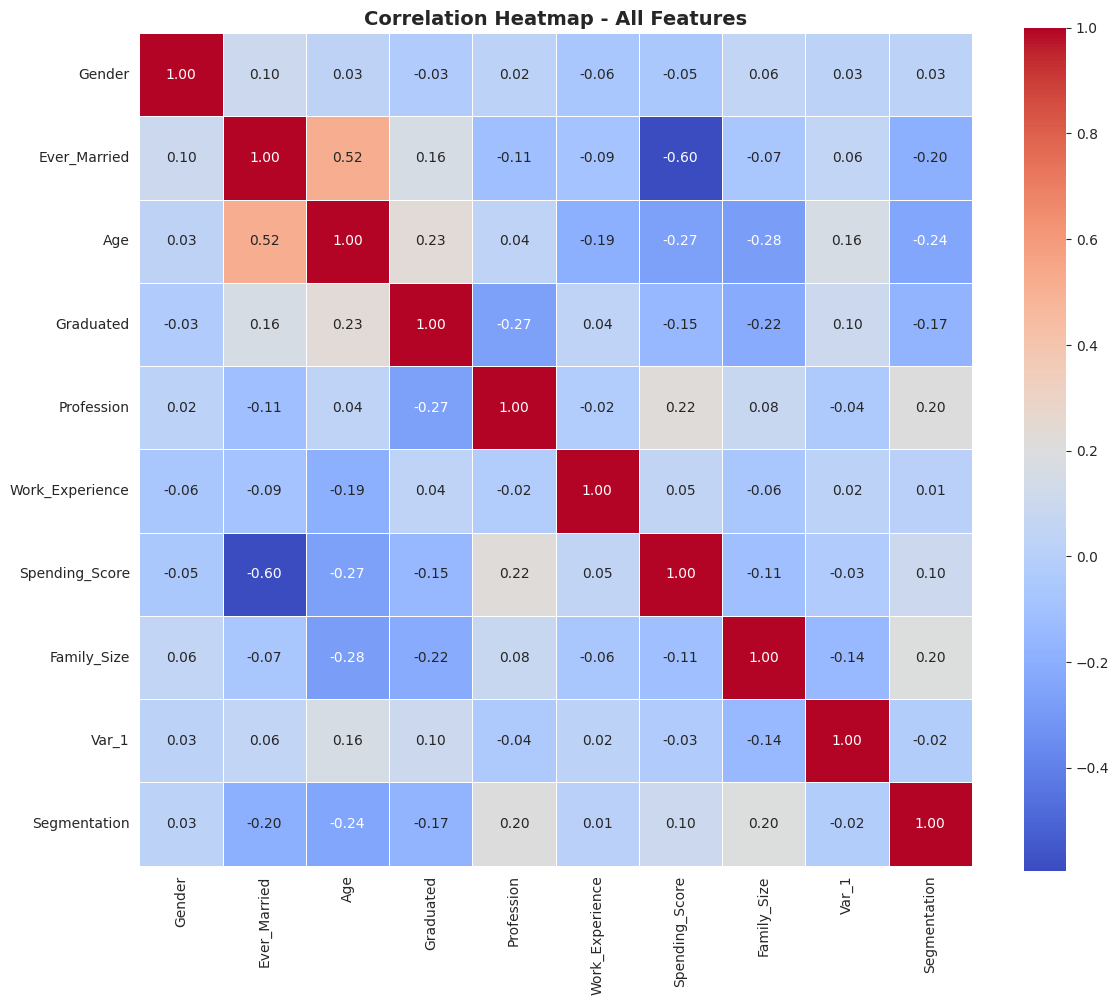

In [58]:
# encoding temporarily for correlation
df_corr = df.copy()
le = LabelEncoder()
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession',
            'Spending_Score', 'Var_1', 'Segmentation']

for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

df_corr = df_corr.drop('ID', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

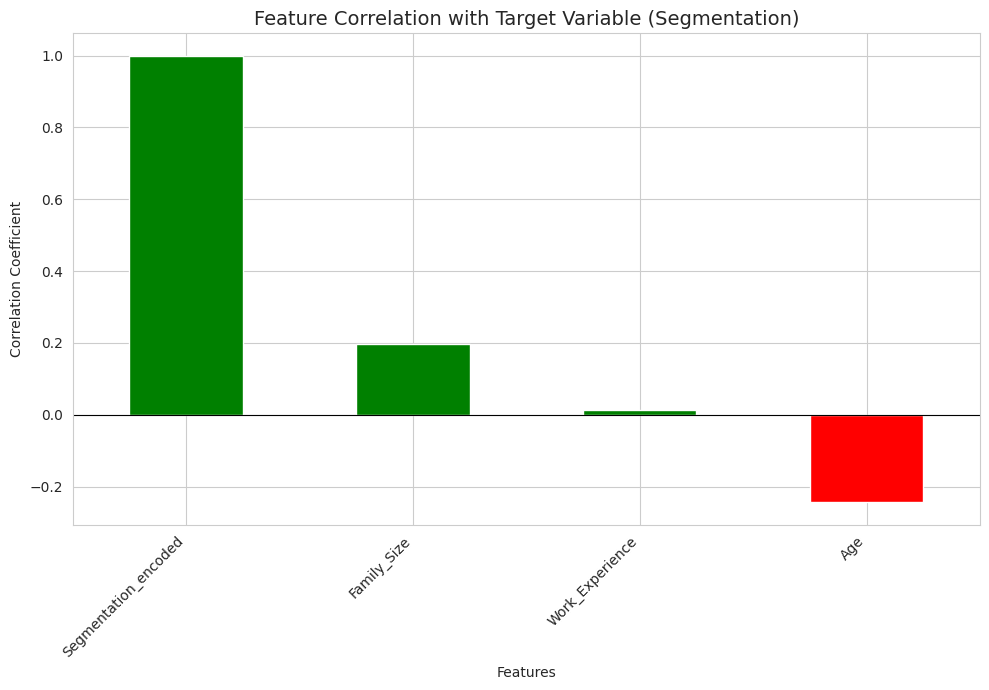

Segmentation_encoded    1.000000
Family_Size             0.196213
Work_Experience         0.012993
Age                    -0.243552
Name: y, dtype: float64


In [59]:
# Finding correltion heatmap with target variable

le = LabelEncoder()
df['Segmentation_encoded'] = le.fit_transform(df['Segmentation'])

numerical_data = df.select_dtypes(include=['int64', 'float64'])
numerical_data['y'] = df['Segmentation_encoded']

corr_matrix = numerical_data.corr()
corr_matrix.drop('ID', axis=0, inplace=True)
corr_matrix.drop('ID', axis=1, inplace=True)

target_corr = corr_matrix['y'].drop('y').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
target_corr.plot(
    kind='bar',
    color=['green' if x > 0 else 'red' for x in target_corr]
)

plt.title('Feature Correlation with Target Variable (Segmentation)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_corr)

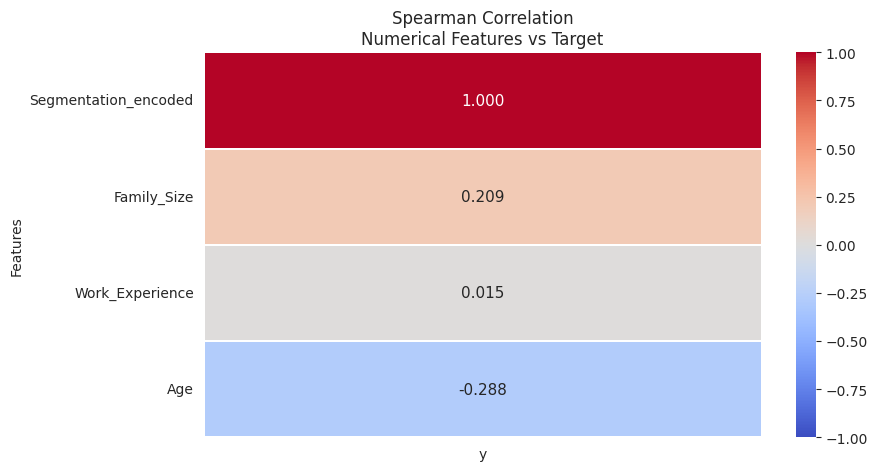

In [60]:
corr_spearman = numerical_data.drop('ID', axis=1) \
    .corr(method='spearman')[['y']] \
    .drop('y') \
    .sort_values(by='y', ascending=False)

plt.figure(figsize=(9, 5))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.3,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 11}
)

plt.title('Spearman Correlation\nNumerical Features vs Target', fontsize=12)
plt.xlabel('')
plt.ylabel('Features')
plt.xticks(rotation=0)

plt.show()

## Check Imbalance in data

In [61]:
df['Segmentation'].value_counts()

,count
Segmentation,
D,2268
A,1972
C,1970
B,1858


/tmp/ipykernel_7513/2803453996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


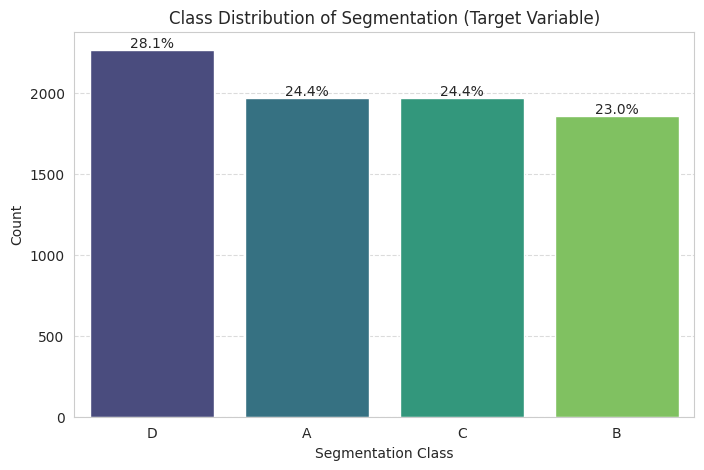

In [62]:
plt.figure(figsize=(8, 5))

target_counts = df['Segmentation'].value_counts().sort_values(ascending=False)

ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')

# Calculate total for percentage
total = target_counts.sum()

# Add percentage labels
for i, value in enumerate(target_counts.values):
    percentage = (value / total) * 100
    ax.text(i, value, f'{percentage:.1f}%', ha='center', va='bottom')

plt.title('Class Distribution of Segmentation (Target Variable)')
plt.xlabel('Segmentation Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Exploratory Data Analysis

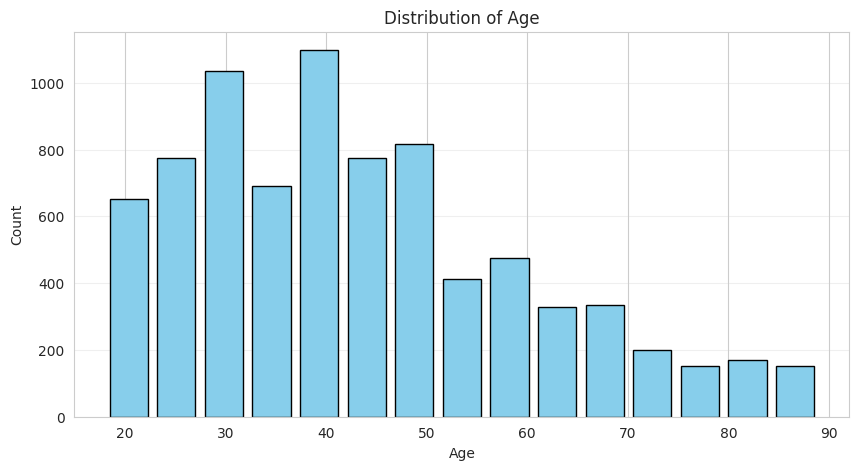

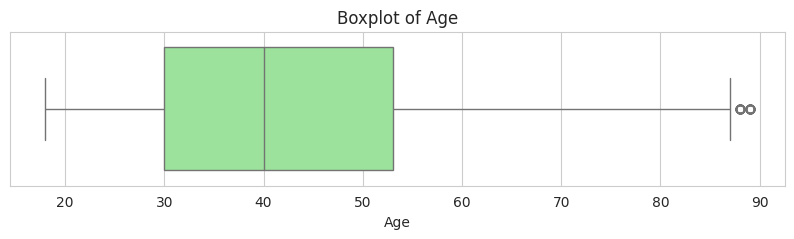

------------------------------


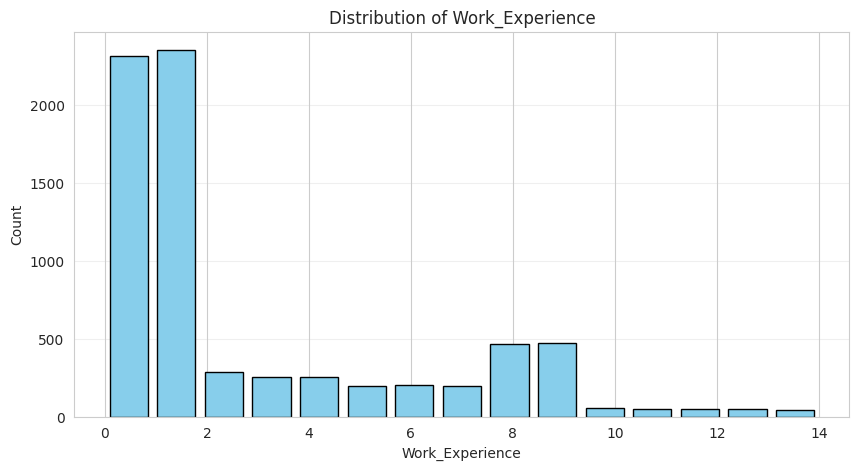

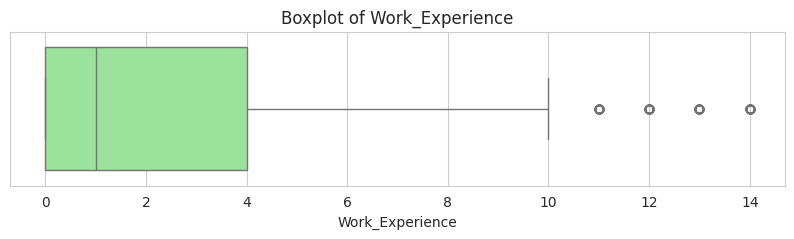

------------------------------


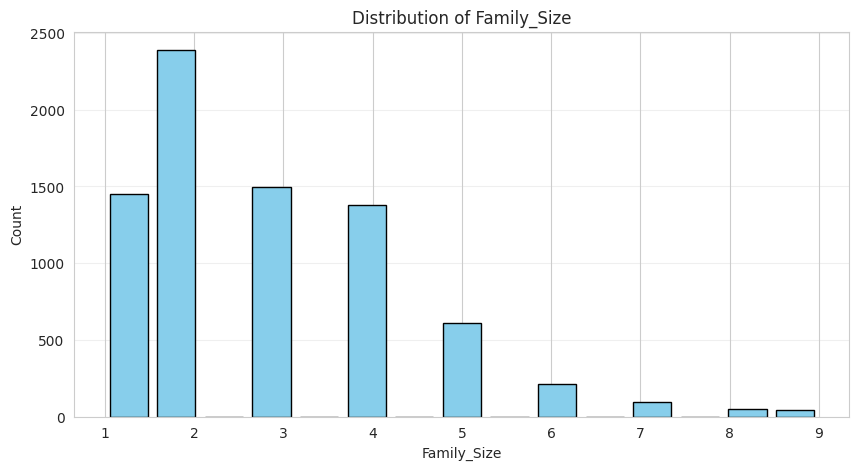

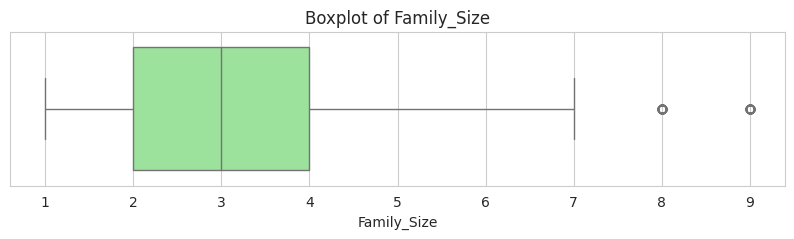

------------------------------


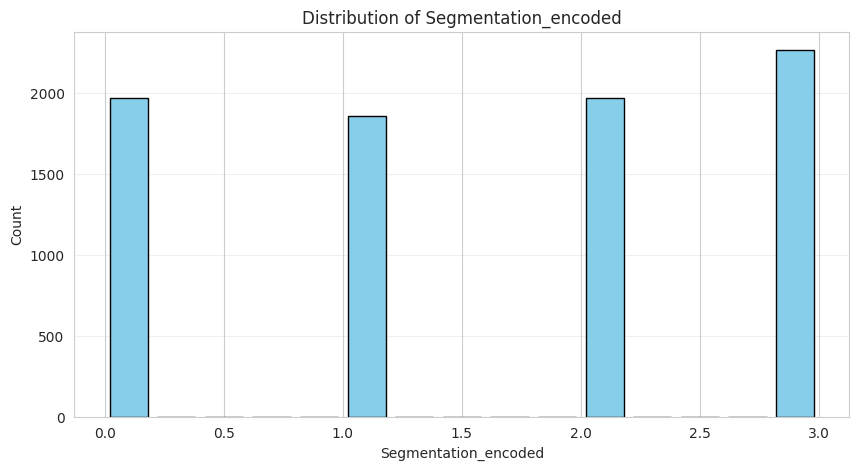

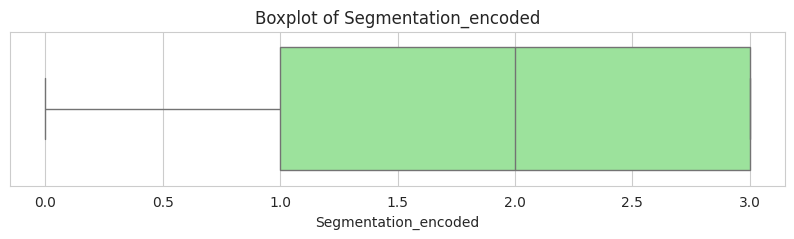

------------------------------


In [63]:
# Distribution of feature through barchart and boxplot
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'ID' in num_cols: num_cols.remove('ID')

for col in num_cols:
    plt.figure(figsize=(10, 5))

    plt.title(f'Distribution of {col}')

    df[col].plot(kind='hist', bins=15, rwidth=0.8, color='skyblue', edgecolor='black')

    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # boxplot seperate plot
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

    print("-" * 30)

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


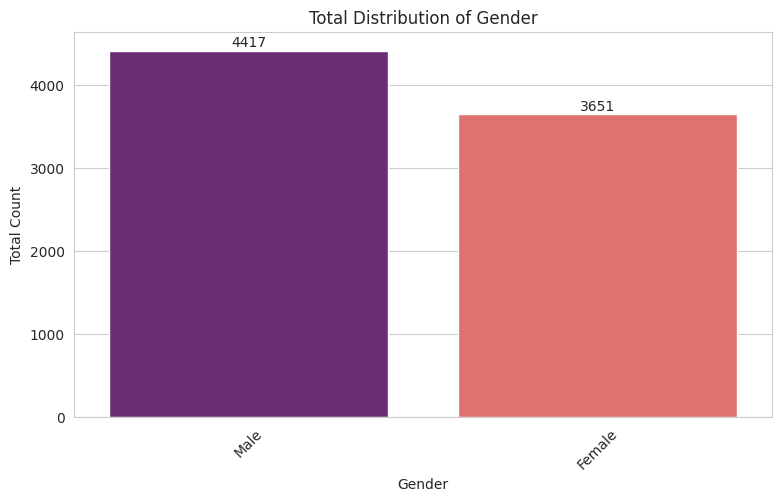

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


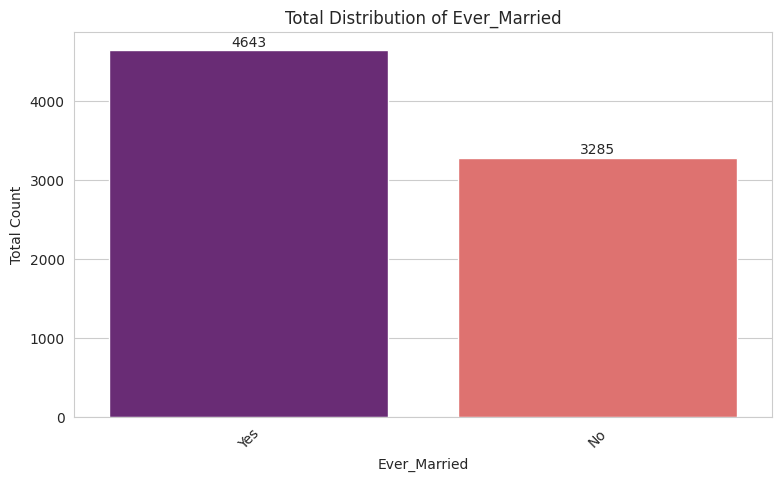

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


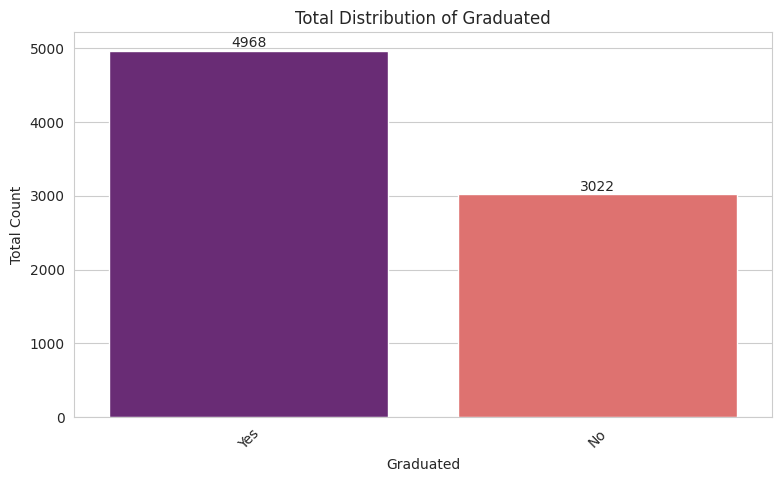

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


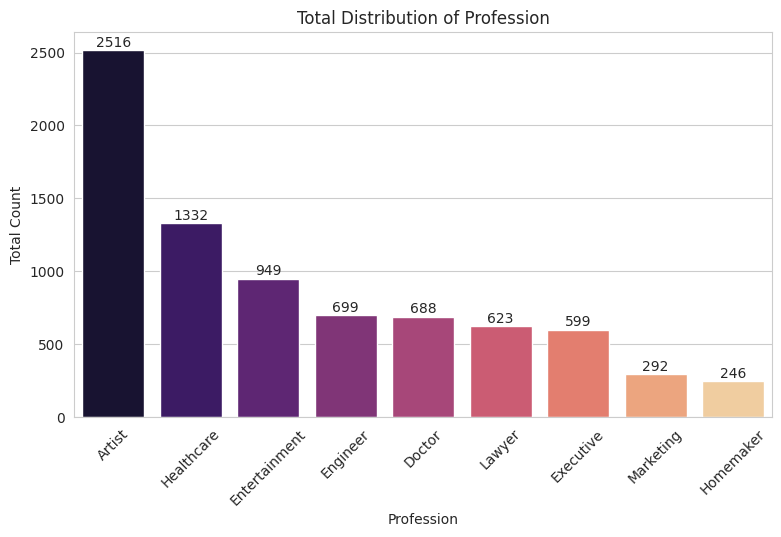

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


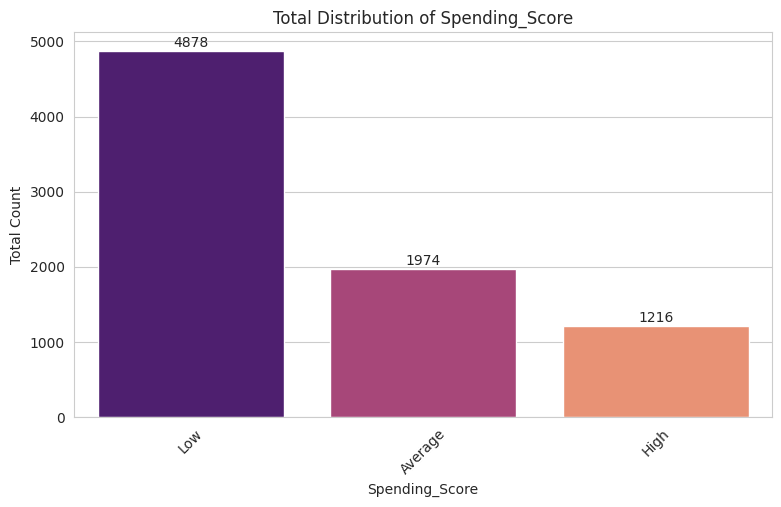

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


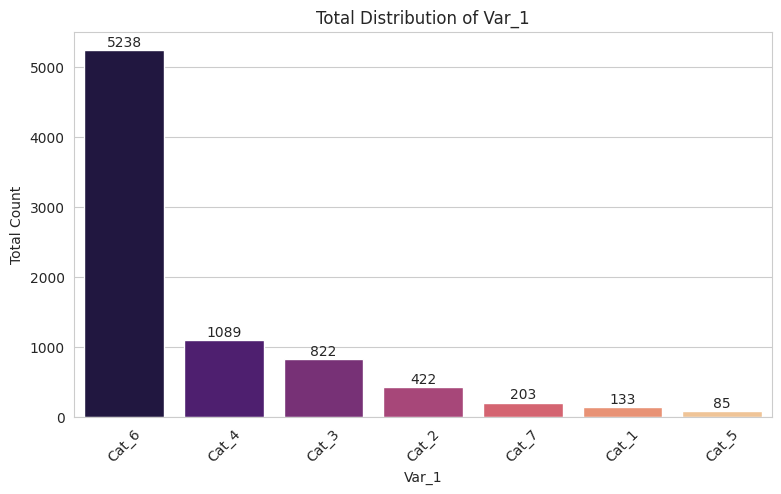

/tmp/ipykernel_7513/1013786182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='magma')


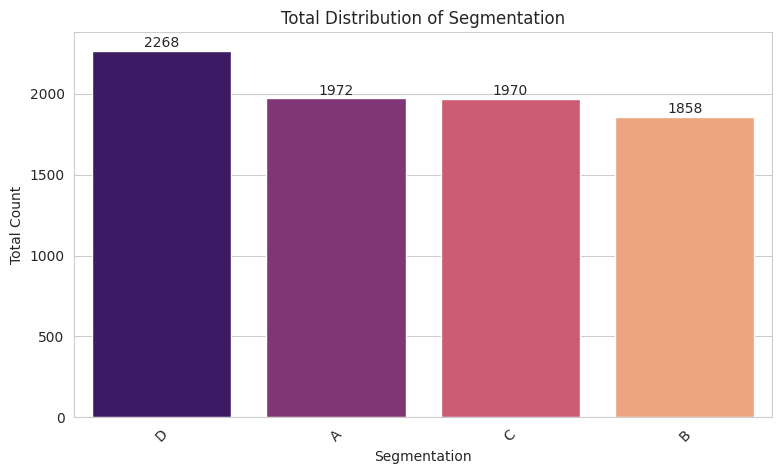

In [64]:
# Distribution of features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(9, 5))
    counts = df[col].value_counts()

    # Create bar chart
    sns.barplot(x=counts.index, y=counts.values, palette='magma')

    plt.title(f'Total Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Total Count')
    plt.xticks(rotation=45)

    # text label on top of bars
    for i, val in enumerate(counts.values):
        plt.text(i, val + (max(counts.values)*0.01), str(val), ha='center')

    plt.show()

/tmp/ipykernel_7513/1281728874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=target, y=col, palette='magma', order=['A', 'B', 'C', 'D'])


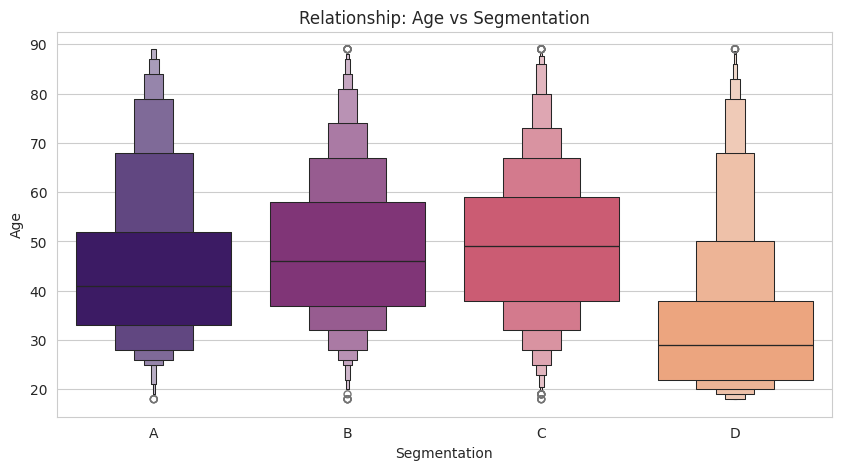

/tmp/ipykernel_7513/1281728874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=target, y=col, palette='magma', order=['A', 'B', 'C', 'D'])


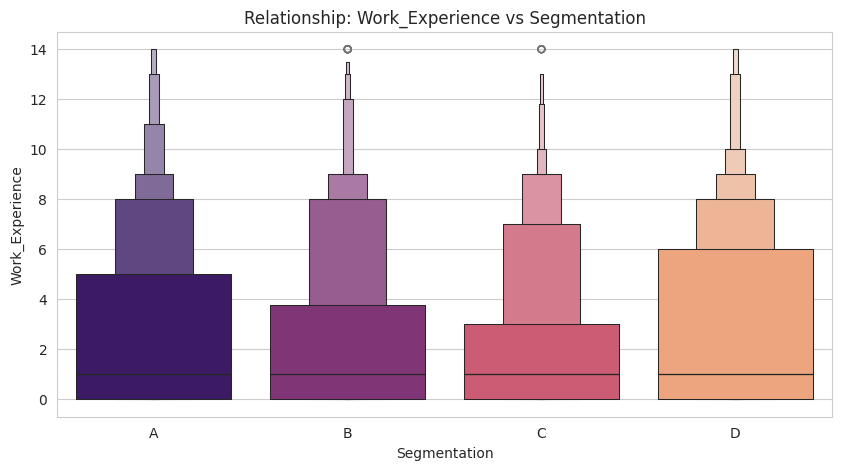

/tmp/ipykernel_7513/1281728874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=target, y=col, palette='magma', order=['A', 'B', 'C', 'D'])


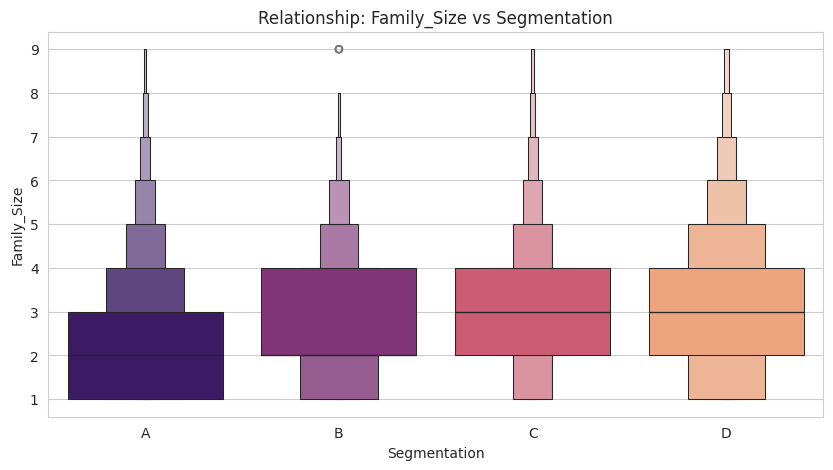

/tmp/ipykernel_7513/1281728874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=target, y=col, palette='magma', order=['A', 'B', 'C', 'D'])


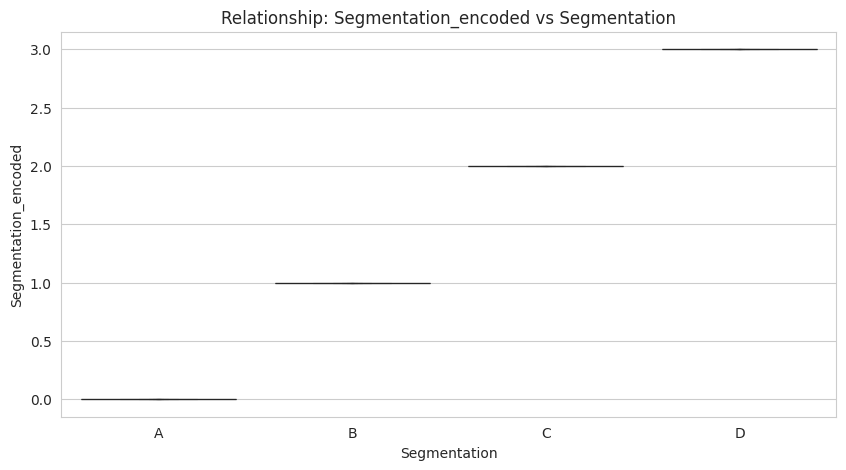

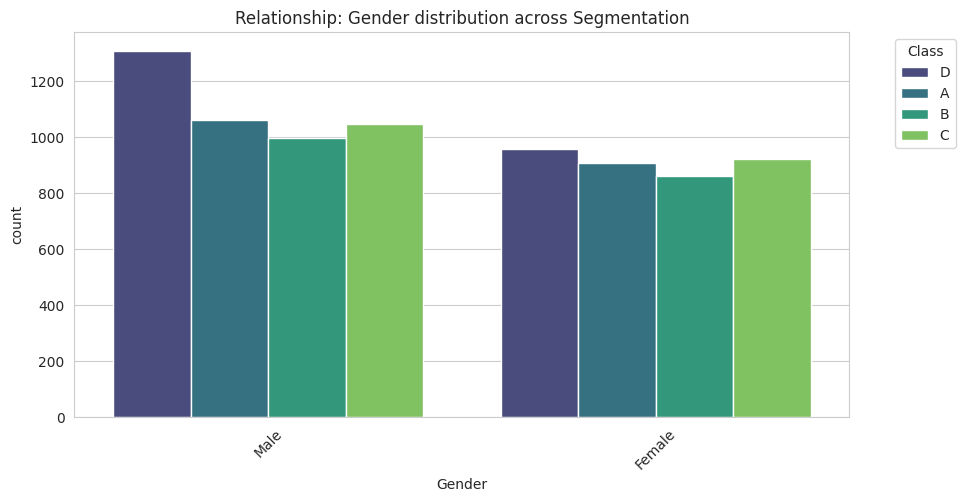

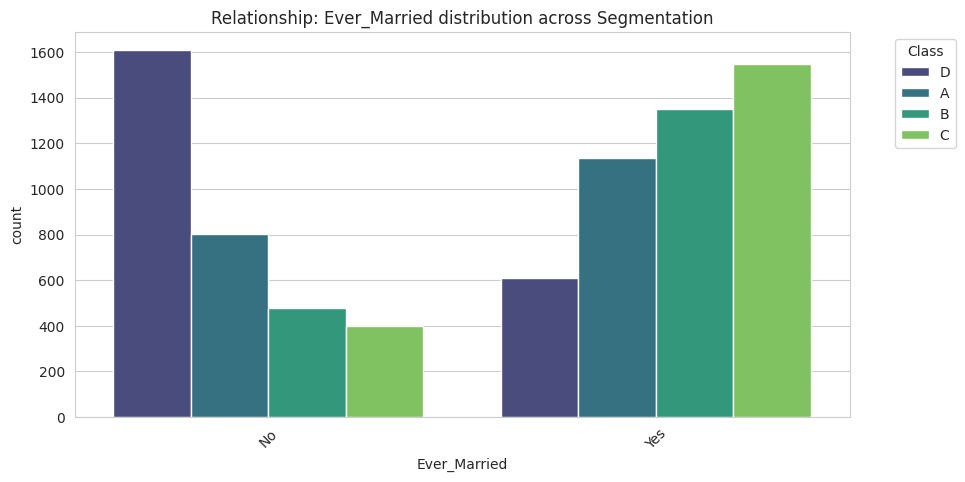

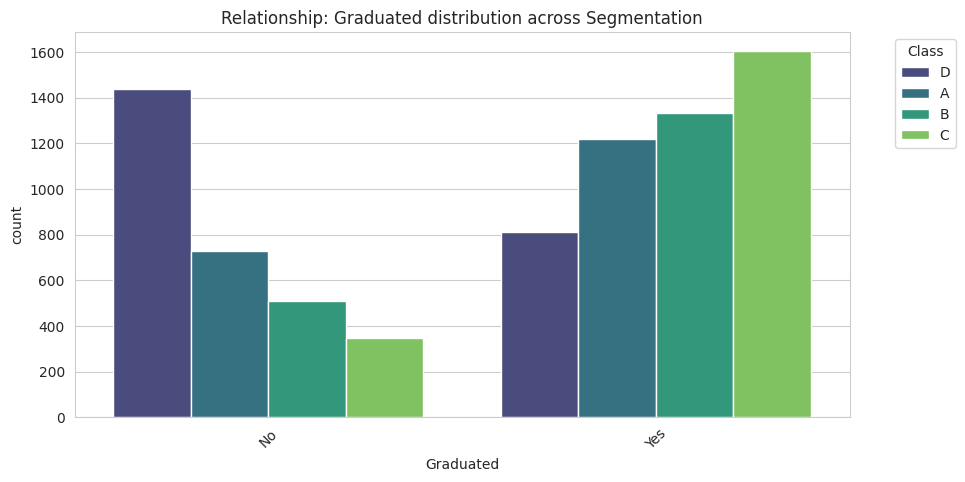

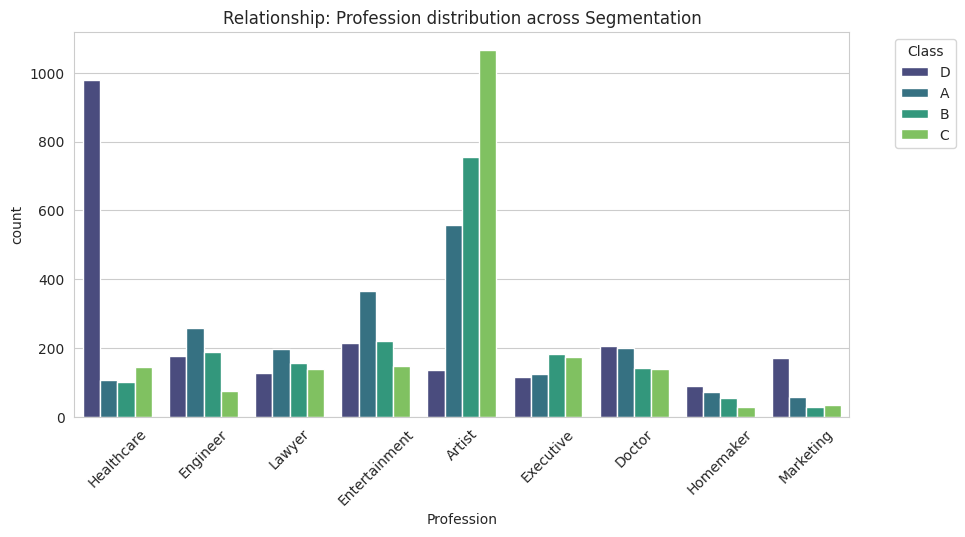

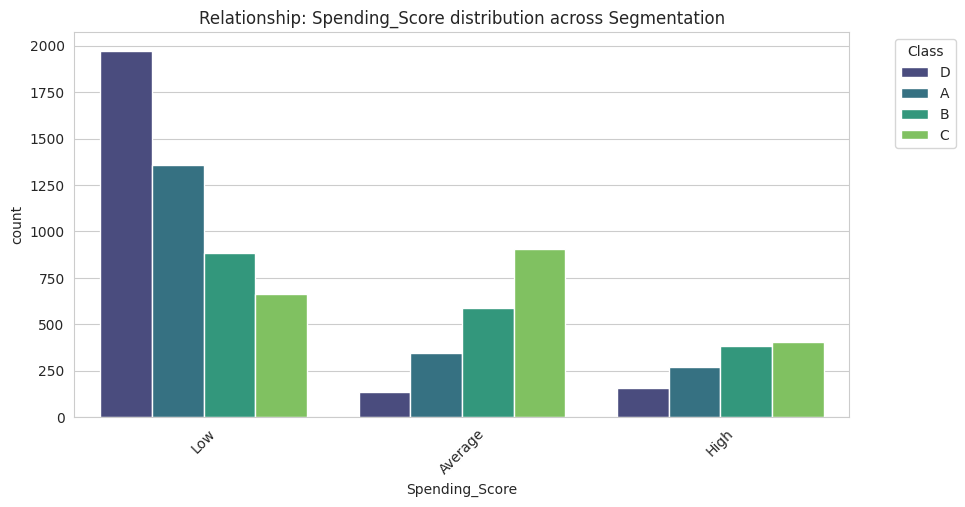

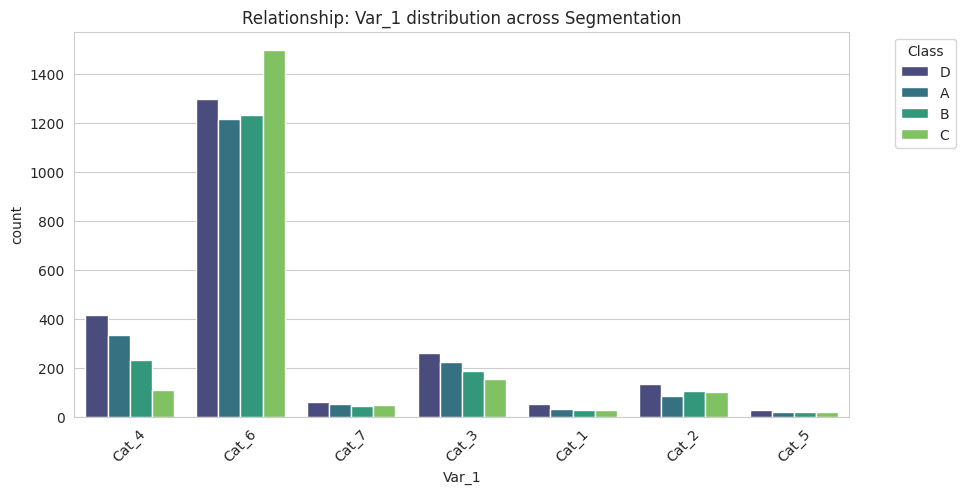

/tmp/ipykernel_7513/1281728874.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')


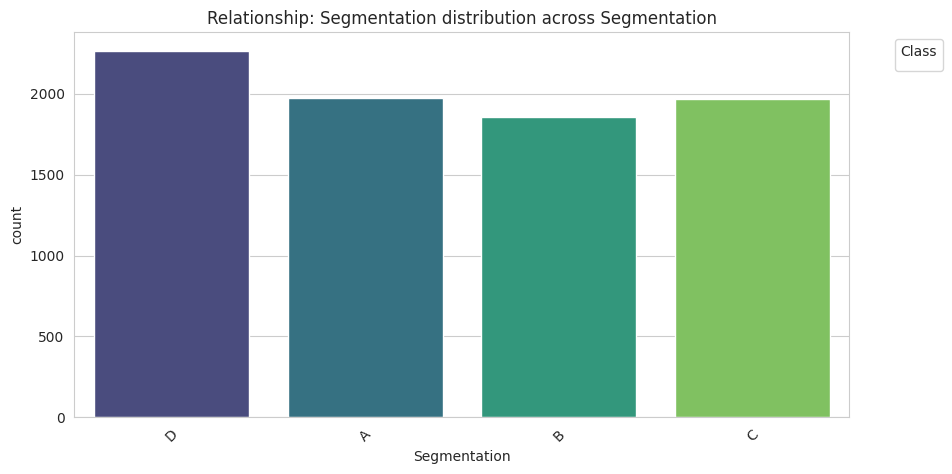

In [65]:
# relation between target and features
target = 'Segmentation'

# num vs Target
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxenplot(data=df, x=target, y=col, palette='magma', order=['A', 'B', 'C', 'D'])
    plt.title(f'Relationship: {col} vs {target}')
    plt.show()

# cate vs Target
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue=target, palette='viridis')
    plt.title(f'Relationship: {col} distribution across {target}')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.show()

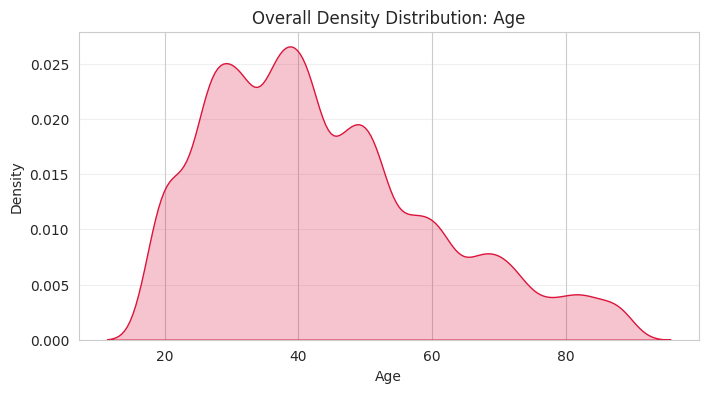

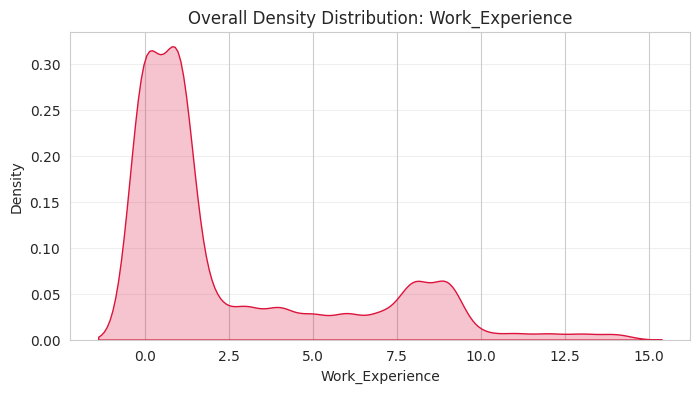

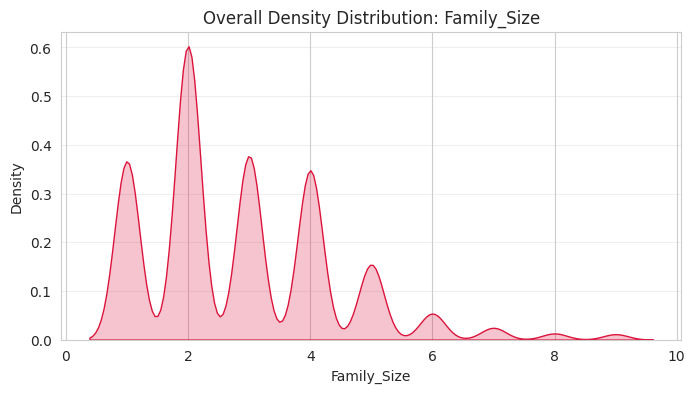

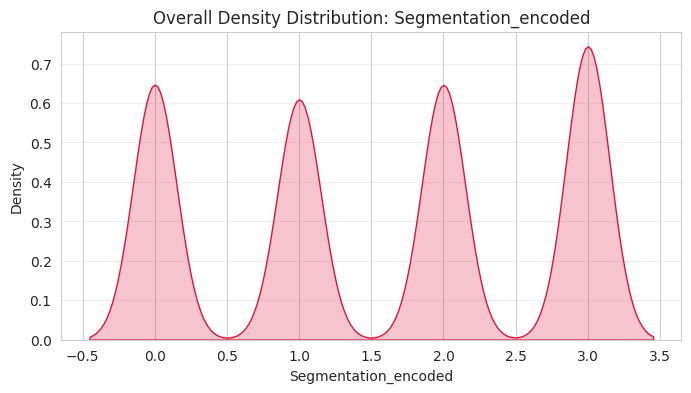

In [66]:
# seperate density plots for numerical data
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'ID' in num_cols: num_cols.remove('ID')

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df[col].dropna(), fill=True, color='crimson', bw_adjust=0.8)
    plt.title(f'Overall Density Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

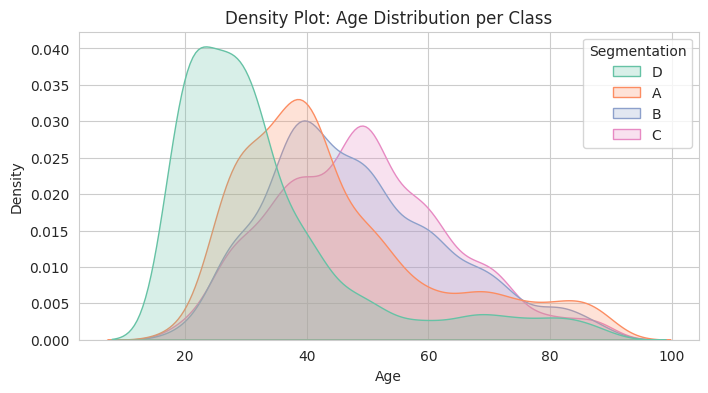

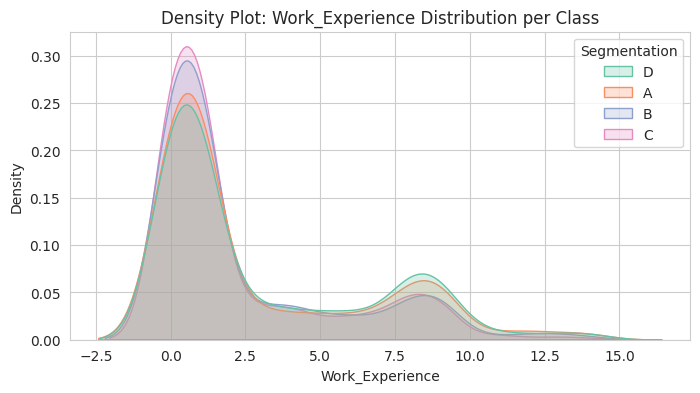

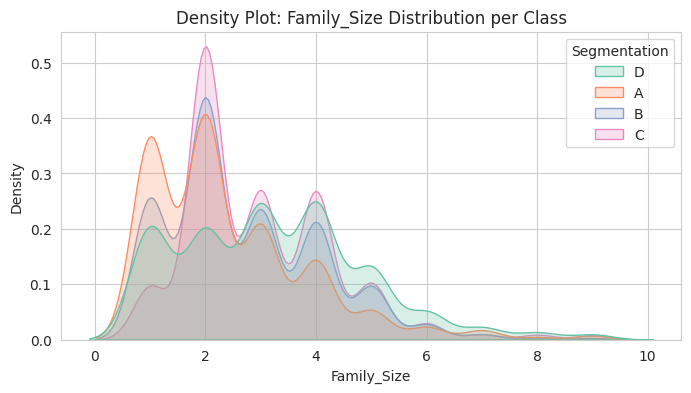

/tmp/ipykernel_7513/1359113084.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue='Segmentation', fill=True, common_norm=False, palette='Set2')


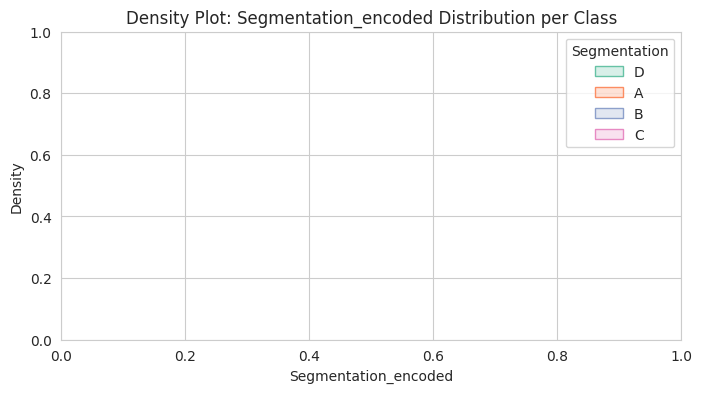

In [67]:
# distribution of featuer per class
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue='Segmentation', fill=True, common_norm=False, palette='Set2')
    plt.title(f'Density Plot: {col} Distribution per Class')
    plt.show()

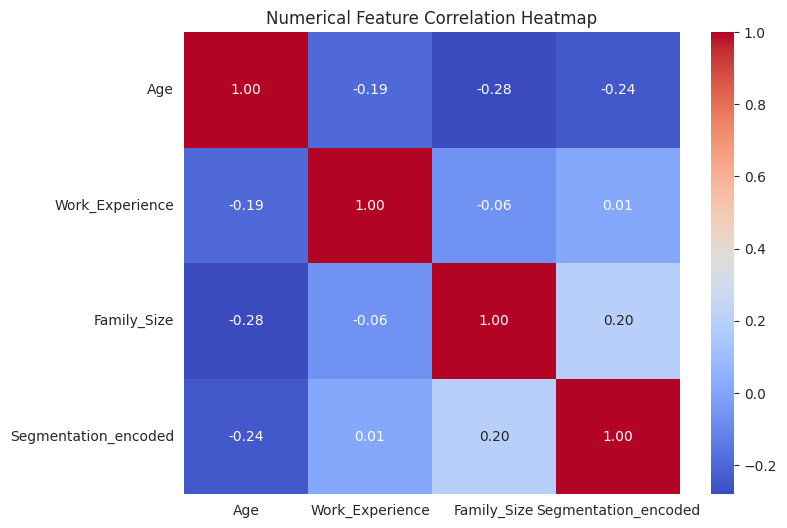

In [68]:
# correlation Heatmap for Numerical Pairs
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()


# 3. Dataset Pre-processing

In [69]:
# check for missing values and counting
missing_values_count = df.isnull().sum()
print("Missing values per feature:")
print(missing_values_count)

Missing values per feature:
ID                        0
Gender                    0
Ever_Married            140
Age                       0
Graduated                78
Profession              124
Work_Experience         829
Spending_Score            0
Family_Size             335
Var_1                    76
Segmentation              0
Segmentation_encoded      0
dtype: int64


In [70]:
# missing values in desc order
sorted_missing_values = missing_values_count.sort_values(ascending=False)
print("Features sorted by missing value count:")
print(sorted_missing_values)

Features sorted by missing value count:
Work_Experience         829
Family_Size             335
Ever_Married            140
Profession              124
Graduated                78
Var_1                    76
ID                        0
Gender                    0
Age                       0
Spending_Score            0
Segmentation              0
Segmentation_encoded      0
dtype: int64


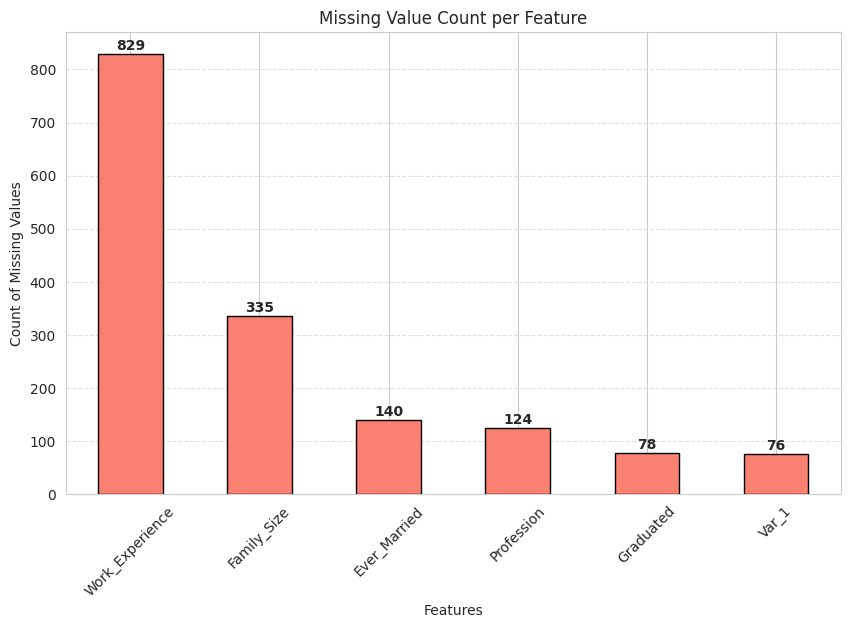

In [71]:
# missing value bar chart
plt.figure(figsize=(10, 6))
plt.title('Missing Value Count per Feature')

# only those who has feature missing
missing_only = sorted_missing_values[sorted_missing_values > 0]

missing_only.plot(kind='bar', rot=45, color='salmon', edgecolor='black')

plt.xlabel('Features')
plt.ylabel('Count of Missing Values')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, val in enumerate(missing_only):
    plt.text(i, val + (max(missing_only)*0.01), str(val), ha='center', fontweight='bold')

plt.show()

In [72]:
# impute num feature with median

df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())
df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())

print(f"Remaining null values in Work_Experience: {df['Work_Experience'].isnull().sum()}")
print(f"Remaining null values in Family_Size: {df['Family_Size'].isnull().sum()}")

Remaining null values in Work_Experience: 0
Remaining null values in Family_Size: 0


In [73]:
# impute categorical features with mode
cat_cols_to_fix = ['Ever_Married', 'Profession', 'Graduated', 'Var_1']

for col in cat_cols_to_fix:
    most_frequent = df[col].mode()[0]
    df[col] = df[col].fillna(most_frequent)

#verify
print(df[cat_cols_to_fix].isnull().sum())

Ever_Married    0
Profession      0
Graduated       0
Var_1           0
dtype: int64


In [74]:
# Final verification
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


# Encoding Categorical values

In [75]:
# binary encoding
le = LabelEncoder()
bin_cols = ['Gender', 'Ever_Married', 'Graduated']
for col in bin_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# one hot encoding
cols_to_dummy = ['Profession', 'Spending_Score', 'Var_1']
df_final = pd.get_dummies(df, columns=cols_to_dummy, drop_first=True)

# target encoding
df_final['Segmentation_encoded'] = le.fit_transform(df['Segmentation'])

df_final = df_final.drop(columns=['Segmentation'], errors='ignore')
if 'ID' in df_final.columns:
    df_final = df_final.drop(columns=['ID'])

print(f"Final shape of encoded dataframe: {df_final.shape}")

Final shape of encoded dataframe: (8068, 23)


In [76]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    8068 non-null   int64  
 1   Ever_Married              8068 non-null   int64  
 2   Age                       8068 non-null   int64  
 3   Graduated                 8068 non-null   int64  
 4   Work_Experience           8068 non-null   float64
 5   Family_Size               8068 non-null   float64
 6   Segmentation_encoded      8068 non-null   int64  
 7   Profession_Doctor         8068 non-null   bool   
 8   Profession_Engineer       8068 non-null   bool   
 9   Profession_Entertainment  8068 non-null   bool   
 10  Profession_Executive      8068 non-null   bool   
 11  Profession_Healthcare     8068 non-null   bool   
 12  Profession_Homemaker      8068 non-null   bool   
 13  Profession_Lawyer         8068 non-null   bool   
 14  Professi

### Dataset Splitting

In [77]:
X = df_final.drop(columns=['Segmentation_encoded'])
y = df_final['Segmentation_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (6454, 22)
Testing set size: (1614, 22)


# 4. Scaling the data

In [78]:
scaler = StandardScaler()
scale_cols = ['Age', 'Work_Experience', 'Family_Size']

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(X_train[scale_cols].head())

           Age  Work_Experience  Family_Size
917  -0.695320         1.970880    -1.231118
3398  1.703982        -0.456381    -0.564314
2045 -0.635337        -0.456381     0.769294
8060  0.264401        -0.759788     2.102901
4604 -0.935250         1.970880    -1.231118


## 5. Model training (Supervised)

### KNN

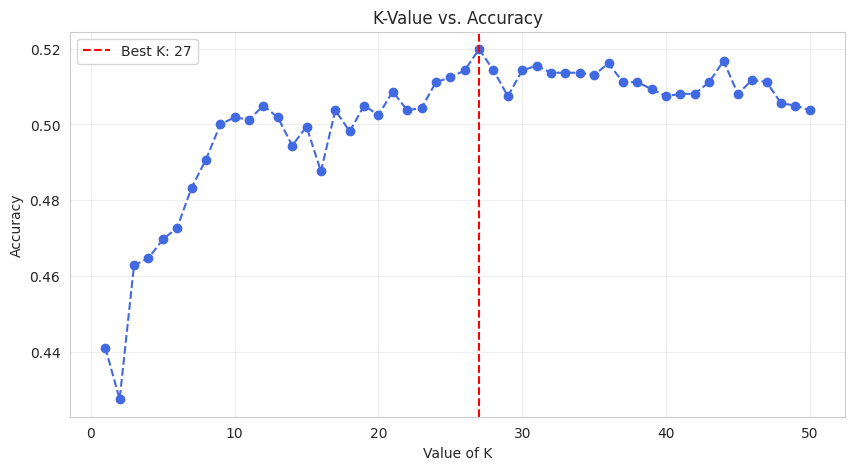

--- KNN Final Results (K=27) ---
Accuracy Score: 0.5198

Classification Report:
              precision    recall  f1-score   support

           A       0.44      0.44      0.44       394
           B       0.40      0.30      0.34       372
           C       0.53      0.61      0.57       394
           D       0.65      0.69      0.67       454

    accuracy                           0.52      1614
   macro avg       0.50      0.51      0.50      1614
weighted avg       0.51      0.52      0.51      1614



In [ ]:
# finding optimal K
k_range = range(1, 50)
accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

best_k = k_range[np.argmax(accuracies)]

# kvalue vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='royalblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K: {best_k}')
plt.title('K-Value vs. Accuracy')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# training with optimal k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# predictions and probabilities
y_pred = knn_final.predict(X_test)
y_probs = knn_final.predict_proba(X_test)

print(f"--- KNN Final Results (K={best_k}) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

if 'model_performance' not in locals():
    model_performance = {}

model_performance['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC_ROC': roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro'),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred),
    'Best_K': best_k
}

### Random Forest

--- Random Forest Results (Manual Params) ---
Accuracy Score: 0.5378

Classification Report:
              precision    recall  f1-score   support

           A       0.45      0.47      0.46       394
           B       0.44      0.28      0.34       372
           C       0.55      0.59      0.57       394
           D       0.64      0.76      0.70       454

    accuracy                           0.54      1614
   macro avg       0.52      0.53      0.52      1614
weighted avg       0.53      0.54      0.53      1614



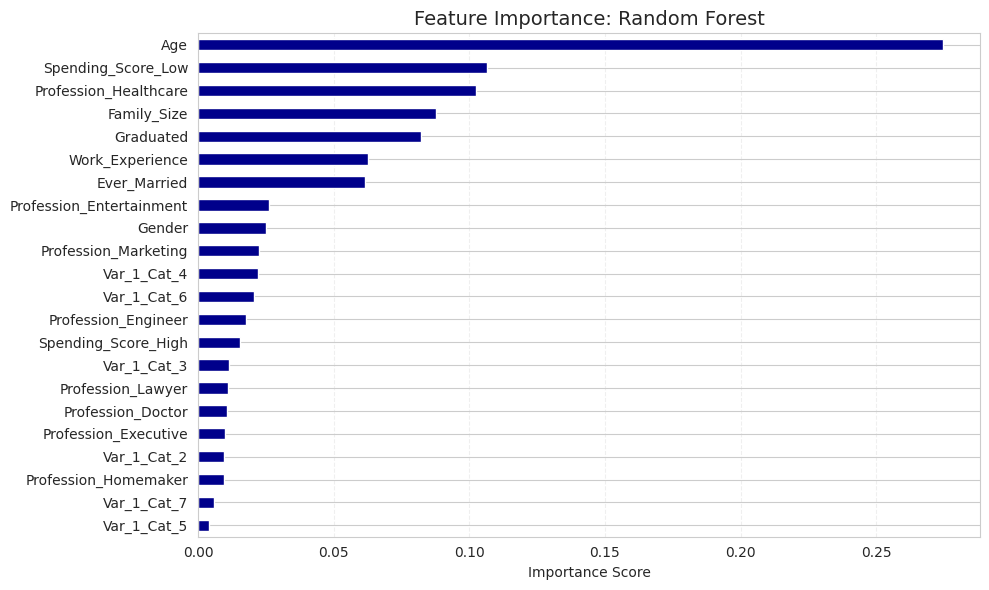

In [80]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1 # use all cpu core
)
rf_final.fit(X_train, y_train)

# predict and prob
y_pred = rf_final.predict(X_test)
y_probs = rf_final.predict_proba(X_test)

# result show
print(f"--- Random Forest Results (Manual Params) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# feature importance graph
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_final.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='darkblue')
plt.title('Feature Importance: Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

if 'model_performance' not in locals():
    model_performance = {}

model_performance['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC_ROC': roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro'),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred)
}


### Decision tree

--- Decision Tree Results (Manual Params) ---
Accuracy Score: 0.5149

Classification Report:
              precision    recall  f1-score   support

           A       0.43      0.41      0.42       394
           B       0.39      0.39      0.39       372
           C       0.59      0.48      0.53       394
           D       0.61      0.74      0.67       454

    accuracy                           0.51      1614
   macro avg       0.51      0.50      0.50      1614
weighted avg       0.51      0.51      0.51      1614



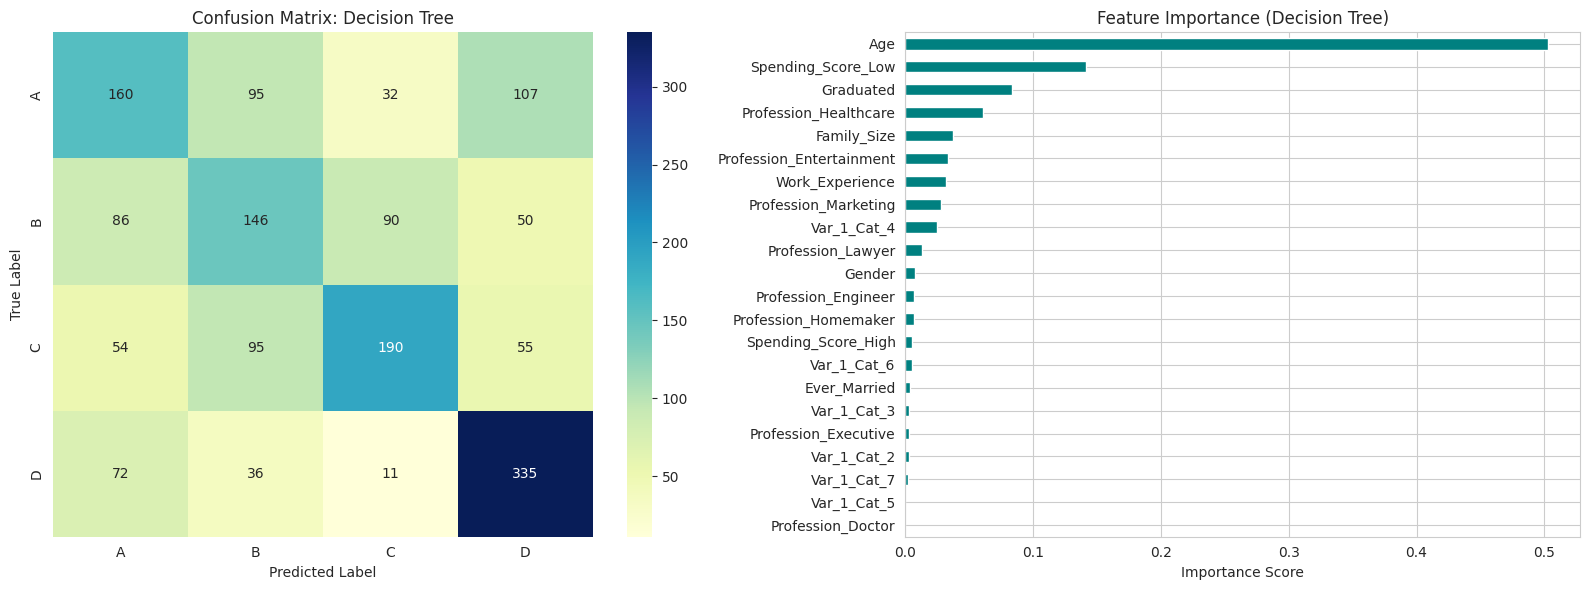

In [81]:
dt_final = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=2,
    random_state=42
)
dt_final.fit(X_train, y_train)

#  predictions and probabilities
y_pred = dt_final.predict(X_test)
y_probs = dt_final.predict_proba(X_test)

# stats
print(f"--- Decision Tree Results (Manual Params) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# visualize
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# showing confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax[0])
ax[0].set_title('Confusion Matrix: Decision Tree')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# chart of feature importance
importances = pd.Series(dt_final.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Feature Importance (Decision Tree)')
ax[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


if 'model_performance' not in locals():
    model_performance = {}

model_performance['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC_ROC': roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro'),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred)
}


### Logistic Regression

In [82]:
log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# predict and probabilities
y_pred = log_reg.predict(X_test)
y_probs = log_reg.predict_proba(X_test)

# report showing
print(f"--- Logistic Regression Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# store metrics
if 'model_performance' not in locals():
    model_performance = {}

model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC_ROC': roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro'),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred)
}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression Results ---
Accuracy Score: 0.5192

Classification Report:
              precision    recall  f1-score   support

           A       0.42      0.45      0.43       394
           B       0.42      0.25      0.32       372
           C       0.51      0.59      0.55       394
           D       0.65      0.74      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.51      0.50      1614
weighted avg       0.51      0.52      0.51      1614



### Neural Network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


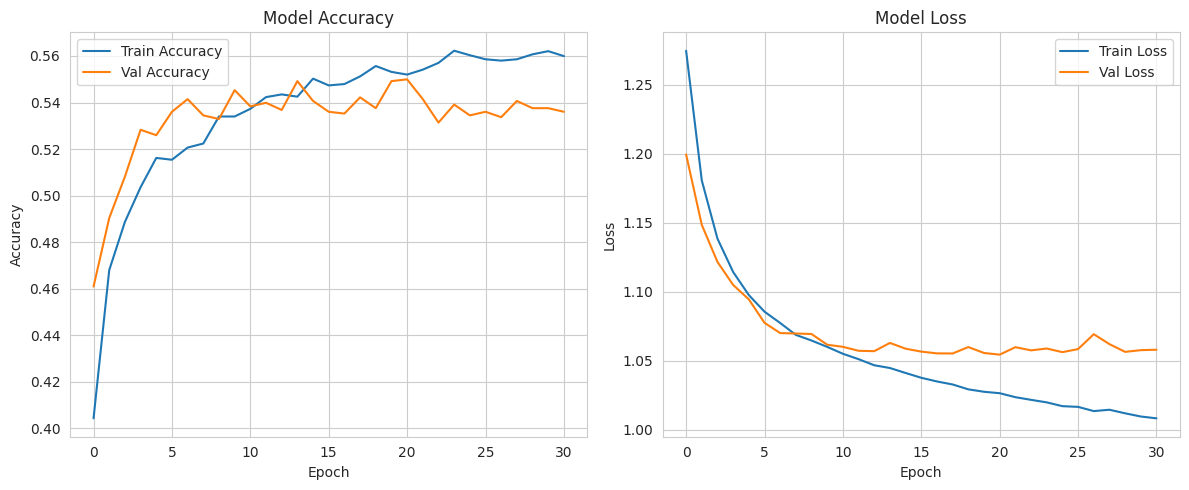

In [83]:
# architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    # output layer
    Dense(4, activation='softmax')
])

# loss function and optimizer
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# showing results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [84]:
# prediction
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

# classification report
print(f"--- Neural Network Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

if 'model_performance' not in locals():
    model_performance = {}

model_performance['Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC_ROC': roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro'),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred)
}


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Neural Network Results ---
Accuracy Score: 0.5341

Classification Report:
              precision    recall  f1-score   support

           A       0.43      0.47      0.45       394
           B       0.45      0.31      0.37       372
           C       0.55      0.55      0.55       394
           D       0.65      0.76      0.70       454

    accuracy                           0.53      1614
   macro avg       0.52      0.52      0.52      1614
weighted avg       0.52      0.53      0.52      1614



### Unsupervised Training: K Means Clustering

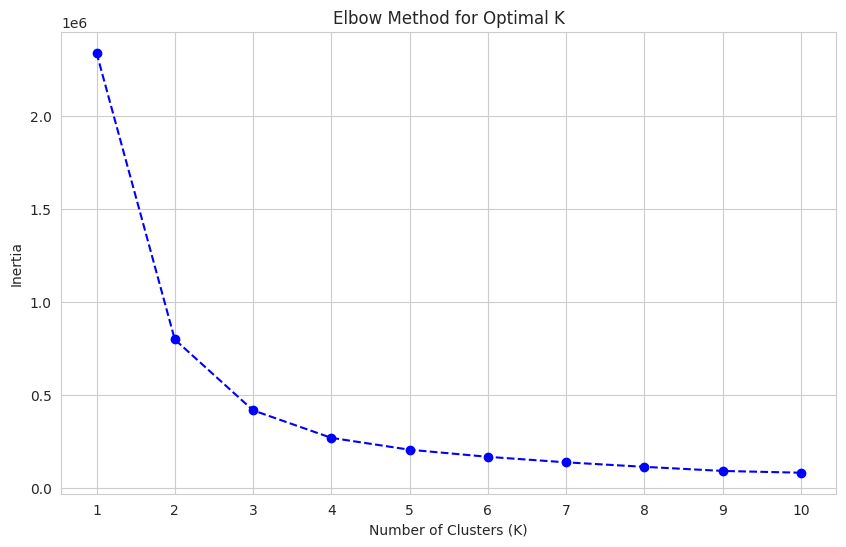

In [ ]:
# dimension reduction using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

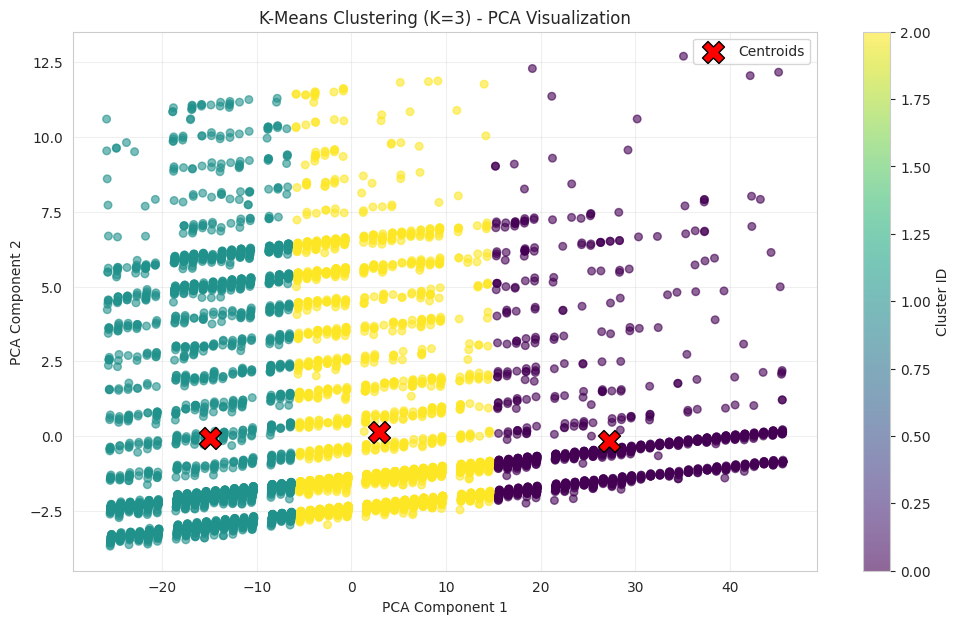

In [86]:
best_k_km = 3

kmeans = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Cluster visualization
plt.figure(figsize=(12, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='viridis', alpha=0.6, s=30)

# centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=250, c='red', label='Centroids', edgecolors='black')

plt.colorbar(scatter, label='Cluster ID')
plt.title(f'K-Means Clustering (K={best_k_km}) - PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Comparison for K=3
Cluster distribution: {1: 3386, 2: 3153, 0: 1529}


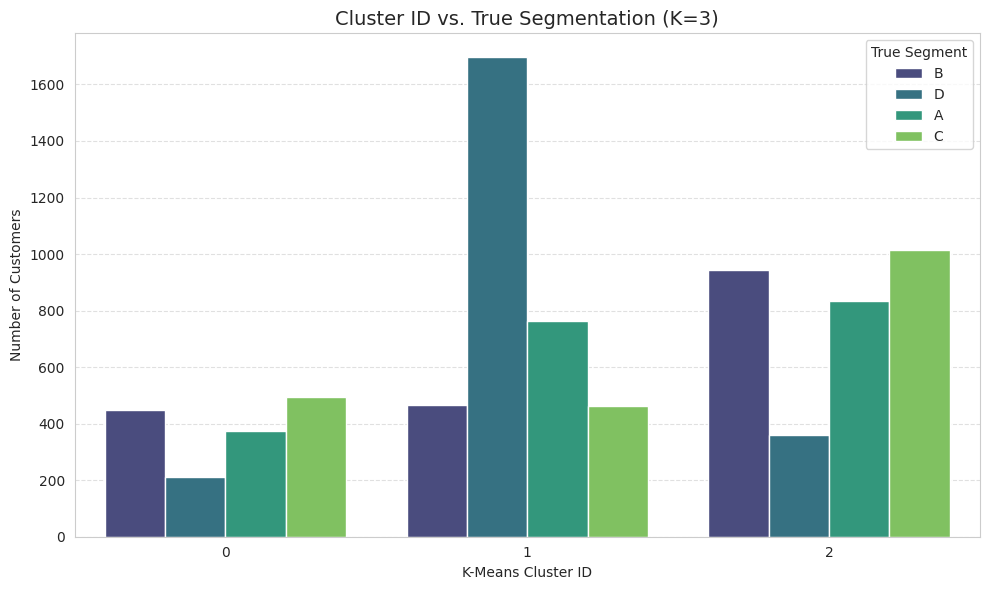

In [98]:
print(f'Comparison for K={best_k_km}')
print('Cluster distribution:', pd.Series(cluster_labels).value_counts().to_dict())

plt.figure(figsize=(10, 6))

y_original = le.inverse_transform(y)
sns.countplot(x=cluster_labels, hue=y_original, palette='viridis')

plt.title(f"Cluster ID vs. True Segmentation (K={best_k_km})", fontsize=14)
plt.xlabel("K-Means Cluster ID")
plt.ylabel("Number of Customers")
plt.legend(title="True Segment", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 6. Model Comparison

### Accuracy comparison

/tmp/ipykernel_7513/2196628671.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Model', y='Accuracy', data=df_compare, palette='viridis')


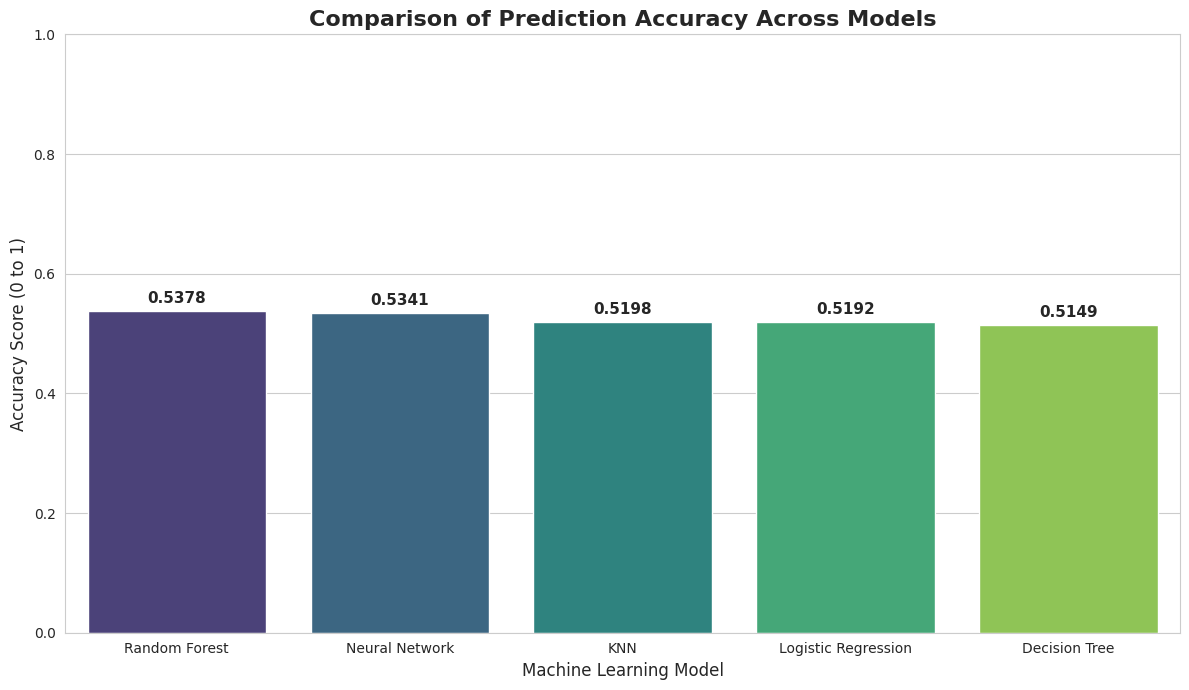

Final Accuracy Comparison Table:
              Model  Accuracy
      Random Forest  0.537794
     Neural Network  0.534077
                KNN  0.519827
Logistic Regression  0.519207
      Decision Tree  0.514870


In [88]:
comparison_data = {
    'Model': list(model_performance.keys()),
    'Accuracy': [model_performance[m]['Accuracy'] for m in model_performance.keys()]
}

df_compare = pd.DataFrame(comparison_data).sort_values(by='Accuracy', ascending=False)

# bar Chart
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# barplot
bars = sns.barplot(x='Model', y='Accuracy', data=df_compare, palette='viridis')

# lableing
plt.title('Comparison of Prediction Accuracy Across Models', fontsize=16, fontweight='bold')
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Accuracy Score (0 to 1)', fontsize=12)
plt.ylim(0, 1.0)

# accuracy values at top
for p in bars.patches:
    bars.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


print("Final Accuracy Comparison Table:")
print(df_compare.to_string(index=False))

### Precision, Recall, F1, AUC

Final Model Performance Table:
              Model  Precision   Recall       F1      AUC
                KNN   0.504039 0.510484 0.504727 0.761653
      Decision Tree   0.505812 0.504671 0.502386 0.761428
      Random Forest   0.519414 0.525733 0.516631 0.789358
Logistic Regression   0.500219 0.507161 0.496985 0.771636
     Neural Network   0.519161 0.522171 0.515818 0.788340


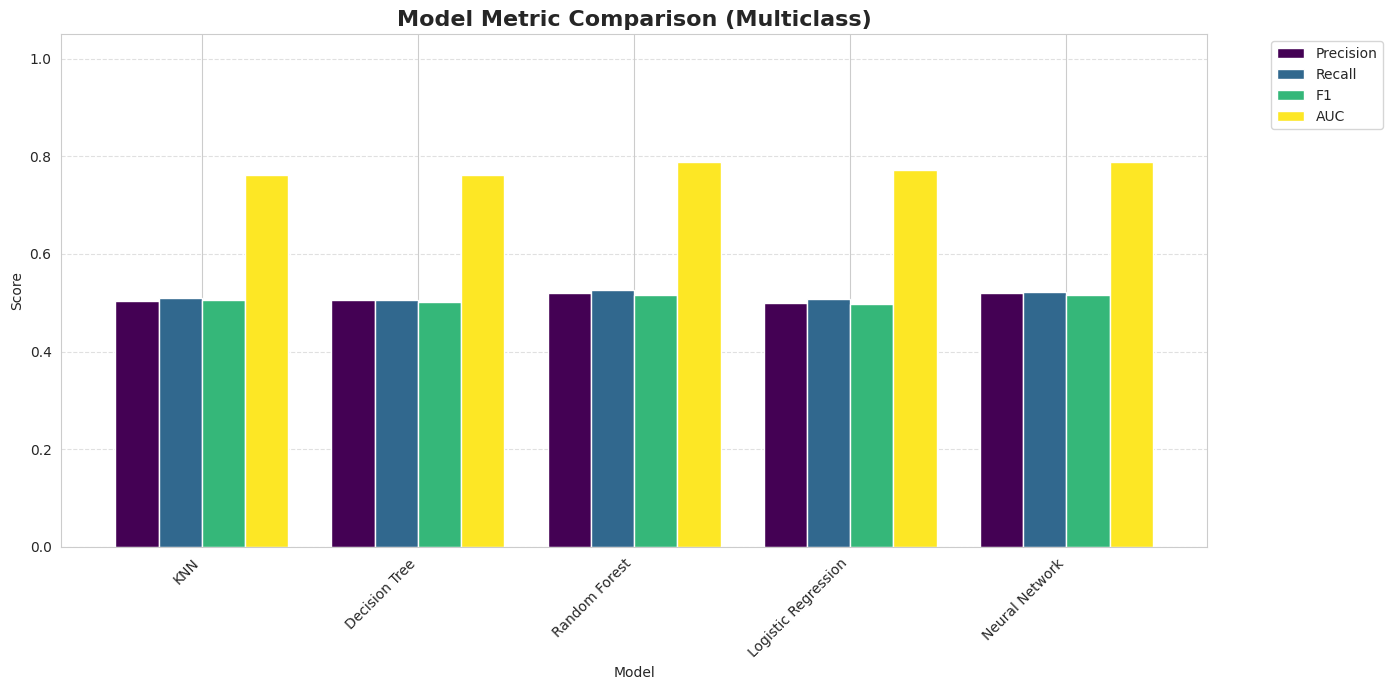

In [89]:
models_to_test = {
    "KNN": knn_final,
    "Decision Tree": dt_final,
    "Random Forest": rf_final,
    "Logistic Regression": log_reg,
    "Neural Network": model
}

results = []

for name, clf in models_to_test.items():
    if name == "Neural Network":
        y_probs = clf.predict(X_test, verbose=0)
        y_pred = np.argmax(y_probs, axis=1)
    else:
        y_probs = clf.predict_proba(X_test)
        y_pred = clf.predict(X_test)

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1": f1_score(y_test, y_pred, average='macro'),
        "AUC": roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')
    })

results_df = pd.DataFrame(results)

print("Final Model Performance Table:")
print(results_df.to_string(index=False))

# bar chart in grp
plot_df = results_df.set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(14, 7), width=0.8, colormap='viridis')

plt.xticks(rotation=45, ha="right")
plt.title("Model Metric Comparison (Multiclass)", fontsize=16, fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### ROC curve

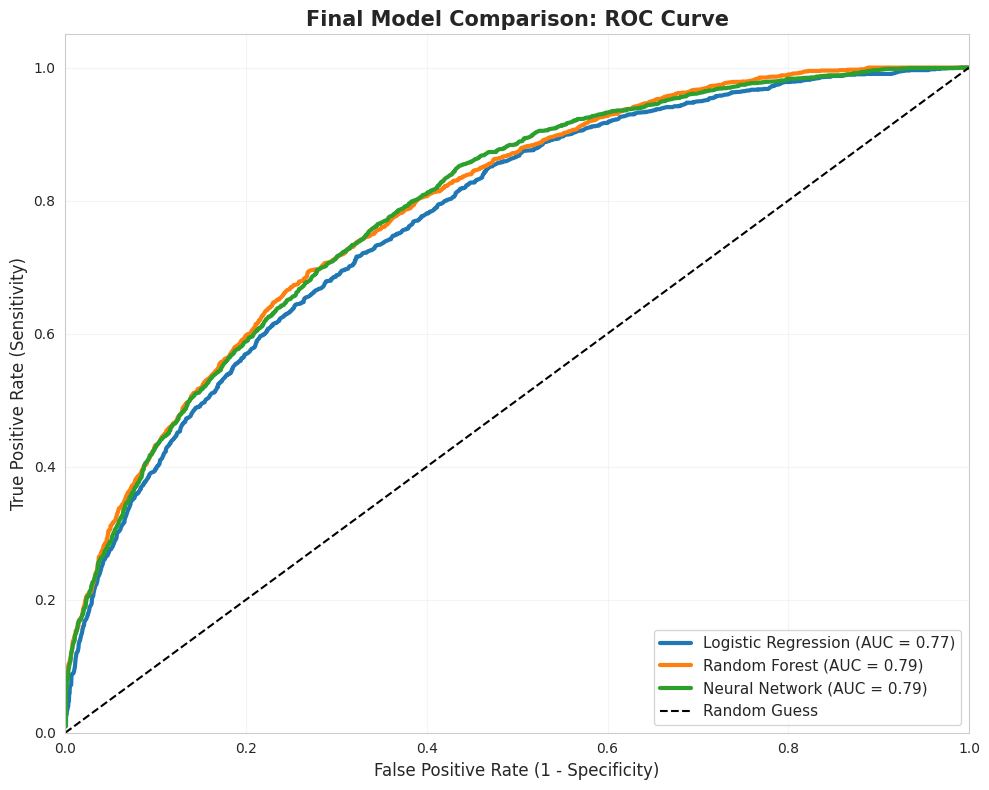

In [90]:
# binarizing output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4

# selecting best models
selected_models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_final,
    "Neural Network": model
}

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (name, clf), color in zip(selected_models.items(), colors):
    if name == "Neural Network":
        y_score = clf.predict(X_test, verbose=0)
    else:
        y_score = clf.predict_proba(X_test)

    fpr = dict()
    tpr = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    # calculate AUC
    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr,
             label=f'{name} (AUC = {roc_auc_macro:.2f})',
             color=color, linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Final Model Comparison: ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 5 fold cross validation

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression: Test Acc = 0.5192, CV Acc = 0.5011
Decision Tree: Test Acc = 0.5149, CV Acc = 0.4919
Random Forest: Test Acc = 0.5378, CV Acc = 0.5209


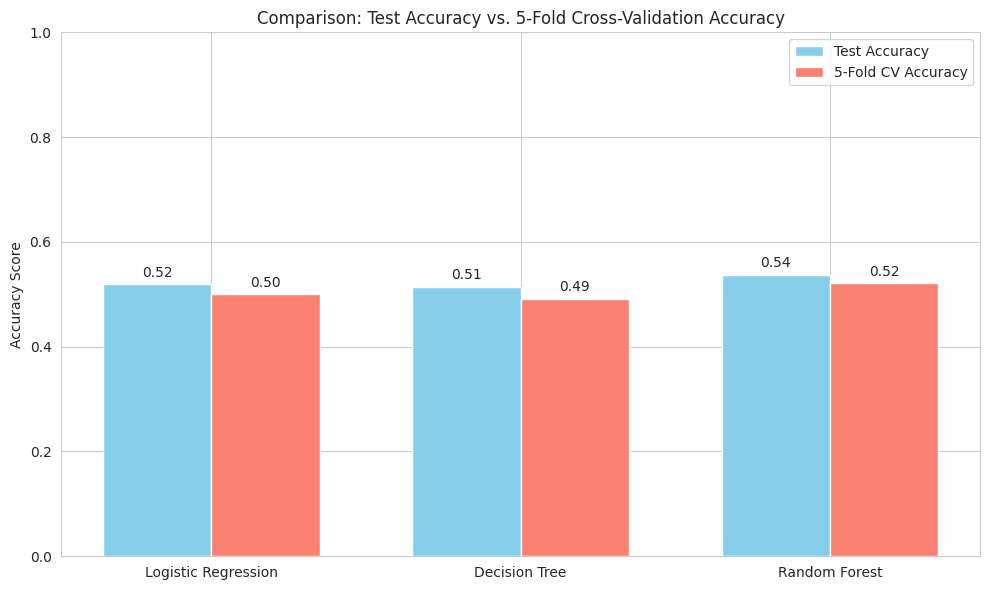

In [91]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt_final,
    'Random Forest': rf_final
}

test_accuracies = []
cv_accuracies = []
model_names = list(models.keys())

for name, model in models.items():
    test_acc = model.score(X_test, y_test)
    test_accuracies.append(test_acc)

   #calculate 5 fold accuracy
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_accuracies.append(cv_scores.mean())

    print(f"{name}: Test Acc = {test_acc:.4f}, CV Acc = {cv_scores.mean():.4f}")

# compare graph
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, test_accuracies, width, label='Test Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, cv_accuracies, width, label='5-Fold CV Accuracy', color='salmon')

ax.set_ylabel('Accuracy Score')
ax.set_title('Comparison: Test Accuracy vs. 5-Fold Cross-Validation Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.0)
ax.legend()

# labeling func
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Confusion matrix comparison

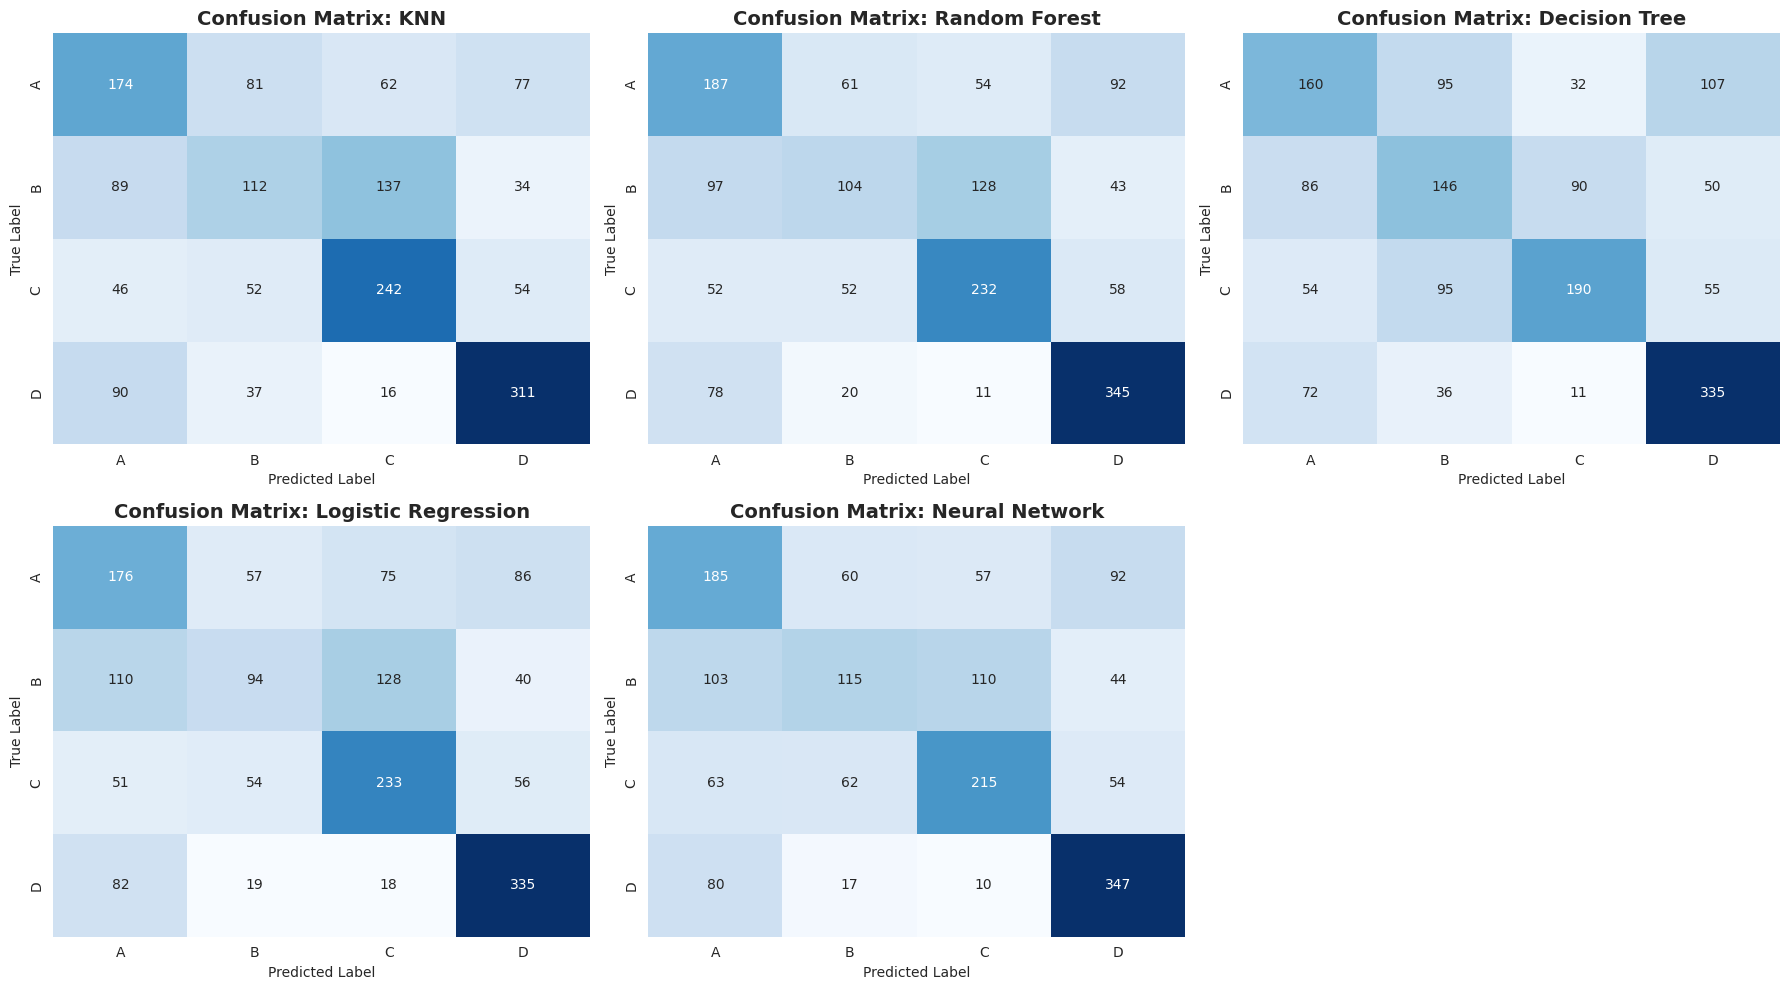

In [92]:
model_names = list(model_performance.keys())
num_models = len(model_names)
cols = 3
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = model_performance[name]['Confusion_Matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                cbar=False, xticklabels=le.classes_, yticklabels=le.classes_)

    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comparing supervised and unsupervised models

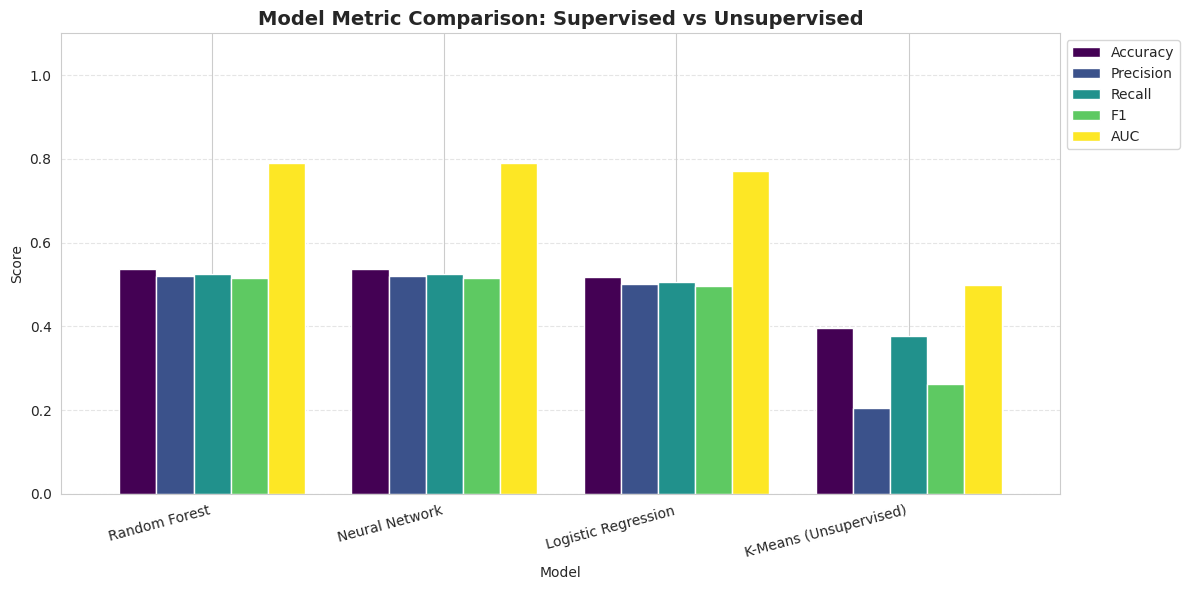

,Model,Accuracy,Precision,Recall,F1,AUC
1,Random Forest,0.537794,0.519414,0.525733,0.516631,0.789358
2,Neural Network,0.537794,0.519414,0.525733,0.516631,0.789358
0,Logistic Regression,0.519207,0.500219,0.507161,0.496985,0.771636
3,K-Means (Unsupervised),0.397124,0.205743,0.378319,0.263332,0.500000


In [93]:
# k means prediction
cluster_map = {}
for i in range(best_k_km):
    mask = (cluster_labels == i)
    if np.any(mask):
        majority_label = pd.Series(y[mask]).mode()[0]
        cluster_map[i] = majority_label

y_pred_kmeans = np.array([cluster_map[label] for label in cluster_labels])

kmeans_results = {
    "Model": "K-Means (Unsupervised)",
    "Accuracy": accuracy_score(y, y_pred_kmeans),
    "Precision": precision_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "Recall": recall_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "F1": f1_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "AUC": 0.50
}

# supervised model prediction
results = []
models_to_eval = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_final,
    "Neural Network": model
}

for name, clf in models_to_eval.items():
    if hasattr(clf, 'predict') and 'keras' in str(type(clf)).lower():
        y_prob = clf.predict(X_test.values.astype('float32'), verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_prob = clf.predict_proba(X_test)
        y_pred = clf.predict(X_test)

    auc_val = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='macro', zero_division=0),
        "AUC": auc_val
    })

# plot
results.append(kmeans_results)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False)

ax = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(
    kind="bar", figsize=(12, 6), width=0.8, colormap='viridis'
)

plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.title("Model Metric Comparison: Supervised vs Unsupervised", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')

plt.tight_layout()
plt.show()

display(results_df)

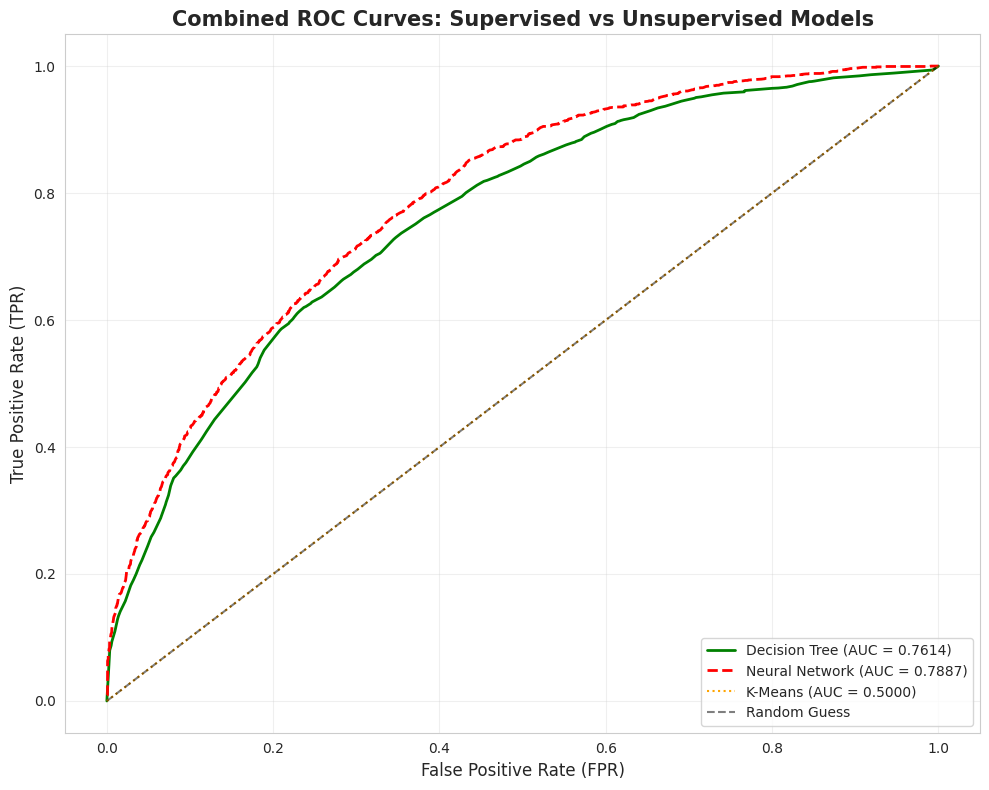

In [94]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4

plt.figure(figsize=(10, 8))

# helper func
def get_macro_roc(y_true_bin, y_score_probs):
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score_probs[:, i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    return all_fpr, mean_tpr

# decision tree
y_prob_dt = dt_final.predict_proba(X_test)
fpr_dt, tpr_dt = get_macro_roc(y_test_bin, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.4f})', color='green', linewidth=2)

# neural network
fpr_nn, tpr_nn = get_macro_roc(y_test_bin, y_probs)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc(fpr_nn, tpr_nn):.4f})', color='red', linestyle='--', linewidth=2)

# K-means
plt.plot([0, 1], [0, 1], color='orange', linestyle=':', label='K-Means (AUC = 0.5000)')

# random classifier
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Combined ROC Curves: Supervised vs Unsupervised Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Final SUmmary


In [95]:
# k mean label
cluster_map = {}
for i in range(best_k_km):
    mask = (cluster_labels == i)
    if np.any(mask):
        majority_label = pd.Series(y[mask]).mode()[0]
        cluster_map[i] = majority_label
y_pred_kmeans = np.array([cluster_map[label] for label in cluster_labels])

results = []

def evaluate_model(name, clf):
    obj_type = str(type(clf)).lower()
    if 'keras' in obj_type or 'sequential' in obj_type:
        y_prob = clf.predict(X_test.values.astype('float32'), verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_prob = clf.predict_proba(X_test)
        y_pred = clf.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='macro', zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    }

results.append(evaluate_model("Random Forest", rf_final))
results.append(evaluate_model("Logistic Regression", log_reg))

if "Neural Network" in selected_models:
    results.append(evaluate_model("Neural Network", selected_models["Neural Network"]))

results.append({
    "Model": "K-Means (Unsupervised)",
    "Accuracy": accuracy_score(y, y_pred_kmeans),
    "Precision": precision_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "Recall": recall_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "F1": f1_score(y, y_pred_kmeans, average='macro', zero_division=0),
    "AUC": 0.50
})

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

print("\n--- Final Model Performance Comparison ---")
display(results_df)


--- Final Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.537794,0.519414,0.525733,0.516631,0.789358
2,Neural Network,0.534077,0.519161,0.522171,0.515818,0.788340
1,Logistic Regression,0.519207,0.500219,0.507161,0.496985,0.771636
3,K-Means (Unsupervised),0.397124,0.205743,0.378319,0.263332,0.500000


# Sample Testing

In [96]:

nn_model = selected_models.get("Neural Network", model)

num_samples = 100
random_indices = np.random.choice(range(len(X_test)), num_samples, replace=False)

summary_results = []

print(f"{'Index':<7} | {'Actual':<10} | {'LR Pred':<10} | {'RF Pred':<10} | {'NN Pred':<10}")
print("-" * 65)

for idx in random_indices:
    sample_input = X_test.iloc[[idx]]

    actual_val = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    actual = le.inverse_transform([actual_val])[0]

    # logistic regression
    lr_idx = log_reg.predict(sample_input)[0]
    lr_p = le.inverse_transform([lr_idx])[0]

    # random forest
    rf_idx = rf_final.predict(sample_input)[0]
    rf_p = le.inverse_transform([rf_idx])[0]

    # neural network
    if 'keras' in str(type(nn_model)).lower() or 'sequential' in str(type(nn_model)).lower():
        nn_input = sample_input.values.astype('float32')
        nn_prob = nn_model.predict(nn_input, verbose=0)
        nn_idx = np.argmax(nn_prob, axis=1)
        nn_p = le.inverse_transform(nn_idx)[0]
    else:
        nn_p = "N/A"

    print(f"{idx:<7} | {actual:<10} | {lr_p:<10} | {rf_p:<10} | {nn_p:<10}")

    summary_results.append({
        'Index': idx,
        'Actual': actual,
        'LR': lr_p,
        'RF': rf_p,
        'NN': nn_p
    })

Index   | Actual     | LR Pred    | RF Pred    | NN Pred   
-----------------------------------------------------------------
369     | C          | C          | C          | C         
1044    | A          | C          | C          | C         
1605    | A          | B          | A          | A         
254     | C          | C          | C          | C         
1466    | D          | D          | D          | D         
1166    | A          | D          | D          | D         
1595    | A          | C          | A          | A         
1492    | A          | A          | A          | A         
160     | A          | A          | A          | A         
1200    | D          | B          | D          | D         
1320    | D          | D          | D          | D         
870     | D          | D          | D          | D         
1594    | B          | C          | C          | C         
551     | C          | C          | C          | C         
885     | D          | D          

In [97]:
# calculate count
lr_correct = sum(1 for res in summary_results if res['Actual'] == res['LR'])
rf_correct = sum(1 for res in summary_results if res['Actual'] == res['RF'])
nn_correct = sum(1 for res in summary_results if res['Actual'] == res['NN'])

print(f"\nSummary of {num_samples} Random Samples:")
print(f"{'Logistic Regression Correct':<26}: {lr_correct}/{num_samples}")
print(f"{'Random Forest Correct':<26}: {rf_correct}/{num_samples}")
print(f"{'Neural Network Correct':<26}: {nn_correct}/{num_samples}")


Summary of 100 Random Samples:
Logistic Regression Correct: 65/100
Random Forest Correct     : 68/100
Neural Network Correct    : 74/100
